# 4 Predictive Analysis

Research question: do Google-search attention factors predict GICS sector returns? This notebook proceeds step by step:

1. Load and align data
2. Exploratory diagnostics
3. In-sample regressions
4. Granger / VAR directional tests
5. OOS forecasting
6. Alpha-style portfolio test


## 1. Load And Align Data

This section pulls monthly sector ETF and SPY returns, aligns them with the Google Trends PCA scores and keyword panel, and constructs both raw sector returns and sector excess returns over SPY. No predictive modeling happens in this section.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import yfinance as yf

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)


In [2]:
# The project-root lookup keeps the notebook runnable from either the repo root or notebooks/.
PROJECT_ROOT = next(
    candidate for candidate in [Path.cwd(), Path.cwd().parent]
    if (candidate / "data/processed/trends_final_filtered.csv").exists()
)
PROCESSED_DATA_DIR = PROJECT_ROOT / "data/processed"
RESULTS_DATA_DIR = PROJECT_ROOT / "data/results"

TRENDS_PATH = PROCESSED_DATA_DIR / "trends_final_filtered.csv"
PCA_SCORES_PATH = PROCESSED_DATA_DIR / "pca_scores.csv"

START_DATE = "2016-05-01"
END_DATE = "2026-06-01"  # yfinance end is exclusive; this includes May 2026 if available.

SECTOR_TICKERS = {
    "Materials": "XLB",
    "Communication Services": "XLC",
    "Energy": "XLE",
    "Financials": "XLF",
    "Industrials": "XLI",
    "Technology": "XLK",
    "Consumer Staples": "XLP",
    "Real Estate": "XLRE",
    "Utilities": "XLU",
    "Health Care": "XLV",
    "Consumer Discretionary": "XLY",
}

MARKET_TICKER = "SPY"
ALL_TICKERS = list(SECTOR_TICKERS.values()) + [MARKET_TICKER]

PC_COUNTS = [5, 10, 13]
HORIZONS = [1, 2]

print(f"Sector tickers: {SECTOR_TICKERS}")
print(f"Market ticker: {MARKET_TICKER}")


Sector tickers: {'Materials': 'XLB', 'Communication Services': 'XLC', 'Energy': 'XLE', 'Financials': 'XLF', 'Industrials': 'XLI', 'Technology': 'XLK', 'Consumer Staples': 'XLP', 'Real Estate': 'XLRE', 'Utilities': 'XLU', 'Health Care': 'XLV', 'Consumer Discretionary': 'XLY'}
Market ticker: SPY


### GICS Sector ETF Proxies

Table X lists the eleven Select Sector SPDR ETFs used as proxies for monthly GICS sector-level equity returns.

In [ ]:
# Create publication-ready GICS sector ETF proxy table.
sector_etf_names = {
    "Materials": "Materials Select Sector SPDR Fund",
    "Communication Services": "Communication Services Select Sector SPDR Fund",
    "Energy": "Energy Select Sector SPDR Fund",
    "Financials": "Financial Select Sector SPDR Fund",
    "Industrials": "Industrial Select Sector SPDR Fund",
    "Technology": "Technology Select Sector SPDR Fund",
    "Consumer Staples": "Consumer Staples Select Sector SPDR Fund",
    "Real Estate": "Real Estate Select Sector SPDR Fund",
    "Utilities": "Utilities Select Sector SPDR Fund",
    "Health Care": "Health Care Select Sector SPDR Fund",
    "Consumer Discretionary": "Consumer Discretionary Select Sector SPDR Fund",
}

sector_etf_table = pd.DataFrame([
    {
        "GICS sector": sector,
        "ETF ticker": ticker,
        "ETF proxy": sector_etf_names[sector],
        "Sample note": (
            "Shorter history following the 2018 GICS Communication Services reclassification"
            if ticker == "XLC" else "Full study-period history available"
        ),
    }
    for sector, ticker in SECTOR_TICKERS.items()
])

sector_etf_table.to_csv(RESULTS_DATA_DIR / "gics_sector_etf_proxies.csv", index=False)

display(
    sector_etf_table.style
    .hide(axis="index")
    .set_caption("Table X: GICS Sector ETF Return Proxies")
)


In [3]:
# Load filtered keyword panel and full-sample PCA scores from the PCA notebook.
# Full-sample PCA scores are useful for diagnostics and in-sample analysis.
# For OOS forecasting later, we will rebuild PCA inside the OOS loop to avoid look-ahead bias.
trends_keywords = pd.read_csv(TRENDS_PATH, index_col=0)
trends_keywords.columns = pd.to_datetime(trends_keywords.columns)
trends_keywords = trends_keywords.apply(pd.to_numeric, errors="coerce").fillna(0)

pca_scores = pd.read_csv(PCA_SCORES_PATH, parse_dates=["date"]).set_index("date").sort_index()
pca_scores.index = pca_scores.index.to_period("M").to_timestamp()

print(f"Filtered keyword panel: {trends_keywords.shape}  (keywords x months)")
print(f"PCA scores: {pca_scores.shape}  (months x PCs)")
print(f"Keyword date range: {trends_keywords.columns.min().date()} to {trends_keywords.columns.max().date()}")
print(f"PCA score date range: {pca_scores.index.min().date()} to {pca_scores.index.max().date()}")
print(f"Stock market anchor present: {'stock market' in trends_keywords.index}")

pca_scores.iloc[:5, :13]


Filtered keyword panel: (163, 121)  (keywords x months)
PCA scores: (121, 121)  (months x PCs)
Keyword date range: 2016-05-01 to 2026-05-01
PCA score date range: 2016-05-01 to 2026-05-01
Stock market anchor present: False


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
date,,,,,,,,,,,,,
2016-05-01,15.270874,7.058147,3.219538,-0.661107,2.313337,-0.854506,2.293406,-0.695372,2.241769,-1.488790,1.794098,-0.356918,0.231584
2016-06-01,1.711560,6.787314,1.805027,-2.083383,3.336154,1.301603,-0.679220,-1.032093,1.956375,0.081326,1.772260,-0.974575,0.600190
2016-07-01,17.449749,7.474903,-0.190481,-4.443894,2.812046,1.433026,-0.902458,-1.816841,2.032350,-0.295101,2.505588,-1.036655,0.489088
2016-08-01,22.880848,7.531968,1.081817,-3.988857,2.021328,1.221206,-1.123180,-2.542899,2.682309,0.900577,1.747872,-1.483248,0.405027
2016-09-01,18.340890,6.591766,4.402958,0.554895,-0.400135,-0.614699,0.615530,-2.719610,2.966655,1.435432,0.085178,0.152876,0.199984


In [4]:
# Download adjusted monthly ETF prices from yfinance.
prices_raw = yf.download(
    ALL_TICKERS,
    start=START_DATE,
    end=END_DATE,
    interval="1mo",
    auto_adjust=True,
    progress=False,
)

if isinstance(prices_raw.columns, pd.MultiIndex):
    if "Close" in prices_raw.columns.get_level_values(0):
        prices = prices_raw["Close"].copy()
    elif "Adj Close" in prices_raw.columns.get_level_values(0):
        prices = prices_raw["Adj Close"].copy()
    else:
        raise ValueError(f"Could not find Close/Adj Close in yfinance columns: {prices_raw.columns}")
else:
    prices = prices_raw.copy()

prices.index = pd.to_datetime(prices.index).tz_localize(None).to_period("M").to_timestamp()
prices = prices.sort_index()
prices = prices.reindex(columns=ALL_TICKERS)

print(f"Downloaded monthly prices: {prices.shape}")
print(f"Price date range: {prices.index.min().date()} to {prices.index.max().date()}")
print("Missing price counts:")
print(prices.isna().sum().sort_values(ascending=False))

prices.head()


Downloaded monthly prices: (121, 12)
Price date range: 2016-05-01 to 2026-05-01
Missing price counts:
Ticker
XLC     25
XLB      0
XLE      0
XLF      0
XLI      0
XLK      0
XLP      0
XLRE     0
XLU      0
XLV      0
XLY      0
SPY      0
dtype: int64


Ticker,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY,SPY
Date,,,,,,,,,,,,
2016-05-01,19.197161,NaN,22.288063,16.003769,46.938000,19.816805,40.299690,22.696089,17.877190,60.375992,35.652065,178.277863
2016-06-01,18.951780,NaN,22.744678,15.404043,47.013542,19.449089,42.205246,23.883507,19.084763,60.680614,35.121136,177.972000
2016-07-01,20.012434,NaN,22.605923,16.021597,48.986073,20.931713,42.112720,24.860676,19.112530,63.889992,36.853210,185.422165
2016-08-01,19.959005,NaN,22.985039,16.638071,49.450275,21.175053,41.866356,23.930140,18.052759,61.816967,36.374592,185.644196
2016-09-01,19.626081,NaN,23.689583,16.094961,49.273033,21.531046,40.965595,23.492828,17.964750,61.264729,36.139801,184.721817


In [5]:
# Convert prices to monthly simple returns.
returns_ticker = prices.pct_change().dropna(how="all")

# Rename sector ETF columns to sector names and keep SPY separately.
ticker_to_sector = {ticker: sector for sector, ticker in SECTOR_TICKERS.items()}
sector_returns = returns_ticker[list(SECTOR_TICKERS.values())].rename(columns=ticker_to_sector)
spy_returns = returns_ticker[[MARKET_TICKER]].rename(columns={MARKET_TICKER: "SPY"})

# Sector excess returns over SPY. This is the main sector-specific target for later tests.
sector_excess_returns = sector_returns.sub(spy_returns["SPY"], axis=0)
sector_excess_returns.columns = [f"{col}_excess" for col in sector_excess_returns.columns]

print(f"Sector returns: {sector_returns.shape}")
print(f"SPY returns: {spy_returns.shape}")
print(f"Sector excess returns: {sector_excess_returns.shape}")
print(f"Return date range: {sector_returns.index.min().date()} to {sector_returns.index.max().date()}")

sector_returns.head()


Sector returns: (120, 11)
SPY returns: (120, 1)
Sector excess returns: (120, 11)
Return date range: 2016-06-01 to 2026-05-01


Ticker,Materials,Communication Services,Energy,Financials,Industrials,Technology,Consumer Staples,Real Estate,Utilities,Health Care,Consumer Discretionary
Date,,,,,,,,,,,
2016-06-01,-0.012782,NaN,0.020487,-0.037474,0.001609,-0.018556,0.047285,0.052318,0.067548,0.005045,-0.014892
2016-07-01,0.055966,NaN,-0.006101,0.040090,0.041957,0.076231,-0.002192,0.040914,0.001455,0.052890,0.049317
2016-08-01,-0.002670,NaN,0.016771,0.038478,0.009476,0.011625,-0.005850,-0.037430,-0.055449,-0.032447,-0.012987
2016-09-01,-0.016680,NaN,0.030652,-0.032643,-0.003584,0.016812,-0.021515,-0.018274,-0.004875,-0.008933,-0.006455
2016-10-01,-0.015896,NaN,-0.022309,0.027688,-0.014685,-0.003429,-0.001560,-0.050549,0.017585,-0.062255,-0.020517


In [6]:
# Align PCA scores and return targets on common monthly dates.
common_idx = pca_scores.index.intersection(sector_returns.index)

pca_scores_aligned = pca_scores.loc[common_idx].copy()
sector_returns_aligned = sector_returns.loc[common_idx].copy()
spy_returns_aligned = spy_returns.loc[common_idx].copy()
sector_excess_aligned = sector_excess_returns.loc[common_idx].copy()

analysis_panel = pd.concat(
    [
        pca_scores_aligned,
        sector_returns_aligned.add_prefix("ret_"),
        sector_excess_aligned.add_prefix("excess_"),
        spy_returns_aligned,
    ],
    axis=1,
)

print(f"Aligned PCA scores: {pca_scores_aligned.shape}")
print(f"Aligned sector returns: {sector_returns_aligned.shape}")
print(f"Aligned sector excess returns: {sector_excess_aligned.shape}")
print(f"Aligned panel: {analysis_panel.shape}")
print(f"Aligned date range: {analysis_panel.index.min().date()} to {analysis_panel.index.max().date()}")
print("\nRemaining missing values by block:")
print({
    "pca_scores": int(pca_scores_aligned.isna().sum().sum()),
    "sector_returns": int(sector_returns_aligned.isna().sum().sum()),
    "sector_excess": int(sector_excess_aligned.isna().sum().sum()),
    "spy_returns": int(spy_returns_aligned.isna().sum().sum()),
})

analysis_panel.head()


Aligned PCA scores: (120, 121)
Aligned sector returns: (120, 11)
Aligned sector excess returns: (120, 11)
Aligned panel: (120, 144)
Aligned date range: 2016-06-01 to 2026-05-01

Remaining missing values by block:
{'pca_scores': 0, 'sector_returns': 25, 'sector_excess': 25, 'spy_returns': 0}


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,PC36,PC37,PC38,PC39,PC40,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50,...,PC95,PC96,PC97,PC98,PC99,PC100,PC101,PC102,PC103,PC104,PC105,PC106,PC107,PC108,PC109,PC110,PC111,PC112,PC113,PC114,PC115,PC116,PC117,PC118,PC119,PC120,PC121,ret_Materials,ret_Communication Services,ret_Energy,ret_Financials,ret_Industrials,ret_Technology,ret_Consumer Staples,ret_Real Estate,ret_Utilities,ret_Health Care,ret_Consumer Discretionary,excess_Materials_excess,excess_Communication Services_excess,excess_Energy_excess,excess_Financials_excess,excess_Industrials_excess,excess_Technology_excess,excess_Consumer Staples_excess,excess_Real Estate_excess,excess_Utilities_excess,excess_Health Care_excess,excess_Consumer Discretionary_excess,SPY
2016-06-01,1.711560,6.787314,1.805027,-2.083383,3.336154,1.301603,-0.679220,-1.032093,1.956375,0.081326,1.772260,-0.974575,0.600190,-0.452605,0.072925,-0.053182,0.033223,-0.594290,-0.104572,0.527951,-0.426630,0.732964,0.085809,-0.012558,0.153424,-0.194667,-0.969187,-0.036442,-0.681302,0.444030,0.102942,0.007468,-0.511921,-0.313413,0.074105,-0.923351,0.235129,-0.122177,0.358451,0.155972,0.693045,-0.182914,0.049333,0.004466,0.032280,0.149137,-0.738119,-0.086030,-0.175386,-0.575854,...,0.097862,0.142744,0.065151,0.087257,-0.022176,0.025422,0.051297,-0.022546,-0.066907,-0.009525,-0.009443,0.042483,0.065509,-0.047124,0.066859,0.011216,-0.018382,-0.039247,-0.080547,-0.078783,0.014285,-0.066188,0.010625,0.004990,-0.017741,0.002677,5.095185e-16,-0.012782,NaN,0.020487,-0.037474,0.001609,-0.018556,0.047285,0.052318,0.067548,0.005045,-0.014892,-0.011066,NaN,0.022203,-0.035758,0.003325,-0.016840,0.049000,0.054034,0.069264,0.006761,-0.013176,-0.001716
2016-07-01,17.449749,7.474903,-0.190481,-4.443894,2.812046,1.433026,-0.902458,-1.816841,2.032350,-0.295101,2.505588,-1.036655,0.489088,-0.336672,0.842916,0.139258,-0.675534,-0.147034,1.038489,-0.006911,-0.104616,-0.300584,1.788561,0.007638,-0.038996,0.291213,-0.037167,-0.466192,-0.606942,-0.562215,-0.727933,0.258893,0.141758,-1.092020,-0.866594,-0.896922,-1.062508,0.297697,0.101773,0.355863,0.370775,-0.796075,0.087388,-0.609011,-0.117803,0.235924,0.742069,0.104866,-0.112948,-0.354155,...,-0.043198,-0.022658,-0.046048,-0.050456,-0.012257,0.015694,-0.013328,-0.040144,-0.000634,0.022611,0.020276,0.002178,0.014407,0.053554,-0.007210,0.027749,-0.006755,0.026274,0.045010,0.009961,0.001839,0.041918,-0.019293,-0.014616,-0.017078,-0.014496,2.321708e-15,0.055966,NaN,-0.006101,0.040090,0.041957,0.076231,-0.002192,0.040914,0.001455,0.052890,0.049317,0.014104,NaN,-0.047962,-0.001771,0.000095,0.034370,-0.044054,-0.000947,-0.040407,0.011028,0.007456,0.041861
2016-08-01,22.880848,7.531968,1.081817,-3.988857,2.021328,1.221206,-1.123180,-2.542899,2.682309,0.900577,1.747872,-1.483248,0.405027,-0.532165,0.504302,0.690885,-1.543804,0.906044,1.057782,0.463198,-1.119226,-0.079315,0.006739,0.999356,-1.005578,-0.091509,-1.036824,0.961068,0.775481,-0.713689,-0.632901,-0.704147,0.428355,1.196124,0.098024,-0.007304,0.743280,0.270566,-0.803057,-0.608978,-0.073612,-0.258511,0.033355,0.346989,0.665776,-0.109933,-0.686195,0.032490,-0.111236,0.118368,...,0.071798,-0.007300,0.091540,-0.054860,0.041854,-0.005752,-0.035629,0.023046,-0.002381,0.033730,0.040442,-0.017147,-0.063487,-0.006417,0.023877,-0.004935,0.007798,-0.026351,-0.001568,0.010075,0.024094,0.016597,0.002801,0.000371,0.023307,0.012694,2.127515e-15,-0.002670,NaN,0.016771,0.038478,0.009476,0.011625,-0.005850,-0.037430,-0.055449,-0.032447,-0.012987,-0.003867,NaN,0.015573,0.037280,0.008279,0.010428,-0.007048,-0.038627,-0.056646,-0.033644,-0.014185,0.001197
2016-09-01,18.340890,6.591766,4.402958,0.554895,-0.400135,-0.614699,0.615530,-2.719610,2.966655,1.435432,0.085178,0.152876,0.199984,0.379634,-0.478884,0.389136,-0.516588,0.580033,1.113390,-0.176628,-1.369471,-0.347962,-1.371965,-0.05

In [7]:
# Save aligned data for later sections.
pca_scores_aligned.to_csv(PROCESSED_DATA_DIR / "aligned_pca_scores.csv")
sector_returns_aligned.to_csv(PROCESSED_DATA_DIR / "aligned_sector_returns.csv")
sector_excess_aligned.to_csv(PROCESSED_DATA_DIR / "aligned_sector_excess_returns.csv")
spy_returns_aligned.to_csv(PROCESSED_DATA_DIR / "aligned_spy_returns.csv")
analysis_panel.to_csv(PROCESSED_DATA_DIR / "analysis_panel.csv")

print("Saved aligned data files:")
print("  aligned_pca_scores.csv")
print("  aligned_sector_returns.csv")
print("  aligned_sector_excess_returns.csv")
print("  aligned_spy_returns.csv")
print("  analysis_panel.csv")


Saved aligned data files:
  aligned_pca_scores.csv
  aligned_sector_returns.csv
  aligned_sector_excess_returns.csv
  aligned_spy_returns.csv
  analysis_panel.csv


## 2. Exploratory Diagnostics

Quick visual and statistical checks before modeling. These diagnostics focus on whether the return data, PC scores, and sector relationships look sensible after alignment.


In [8]:
import matplotlib.pyplot as plt

SECTOR_NAMES = list(SECTOR_TICKERS.keys())
PC_DIAGNOSTIC_COUNT = 13
PC_DIAGNOSTIC_COLS = [f"PC{i}" for i in range(1, PC_DIAGNOSTIC_COUNT + 1)]

# Keep Communication Services separate in diagnostics when full-sample missing values matter.
sector_missing = sector_returns_aligned.isna().sum().sort_values(ascending=False)
full_sample_sectors = sector_missing[sector_missing == 0].index.tolist()

print("Missing monthly return observations by sector:")
print(sector_missing)
print(f"\nSectors with complete return history: {len(full_sample_sectors)}")
print(full_sample_sectors)


Missing monthly return observations by sector:
Ticker
Communication Services    25
Materials                  0
Energy                     0
Financials                 0
Industrials                0
Technology                 0
Consumer Staples           0
Real Estate                0
Utilities                  0
Health Care                0
Consumer Discretionary     0
dtype: int64

Sectors with complete return history: 10
['Materials', 'Energy', 'Financials', 'Industrials', 'Technology', 'Consumer Staples', 'Real Estate', 'Utilities', 'Health Care', 'Consumer Discretionary']


In [9]:
# Sector return summary statistics
summary_stats = pd.DataFrame({
    "mean_monthly": sector_returns_aligned.mean(),
    "vol_monthly": sector_returns_aligned.std(),
    "ann_return_approx": sector_returns_aligned.mean() * 12,
    "ann_vol": sector_returns_aligned.std() * np.sqrt(12),
    "ann_sharpe_approx": (sector_returns_aligned.mean() / sector_returns_aligned.std()) * np.sqrt(12),
    "min_monthly": sector_returns_aligned.min(),
    "max_monthly": sector_returns_aligned.max(),
    "missing": sector_returns_aligned.isna().sum(),
}).round(4)

summary_stats.sort_values("ann_sharpe_approx", ascending=False)


,mean_monthly,vol_monthly,ann_return_approx,ann_vol,ann_sharpe_approx,min_monthly,max_monthly,missing
Ticker,,,,,,,,
Technology,0.0203,0.0591,0.2434,0.2046,1.1894,-0.1218,0.2016,0
Industrials,0.0124,0.0553,0.1487,0.1915,0.7767,-0.1925,0.1603,0
Communication Services,0.0113,0.0552,0.1352,0.1913,0.7066,-0.1391,0.1506,25
Financials,0.0115,0.0572,0.1380,0.1981,0.6966,-0.2170,0.1685,0
Health Care,0.0085,0.0422,0.1018,0.1463,0.6959,-0.0976,0.1313,0
Consumer Discretionary,0.0118,0.0592,0.1419,0.2051,0.6918,-0.1532,0.1946,0
Utilities,0.0088,0.0457,0.1060,0.1584,0.6689,-0.1188,0.1036,0
Consumer Staples,0.0070,0.0391,0.0837,0.1354,0.6183,-0.0974,0.0972,0
Materials,0.0095,0.0546,0.1145,0.1890,0.6056,-0.1457,0.1596,0


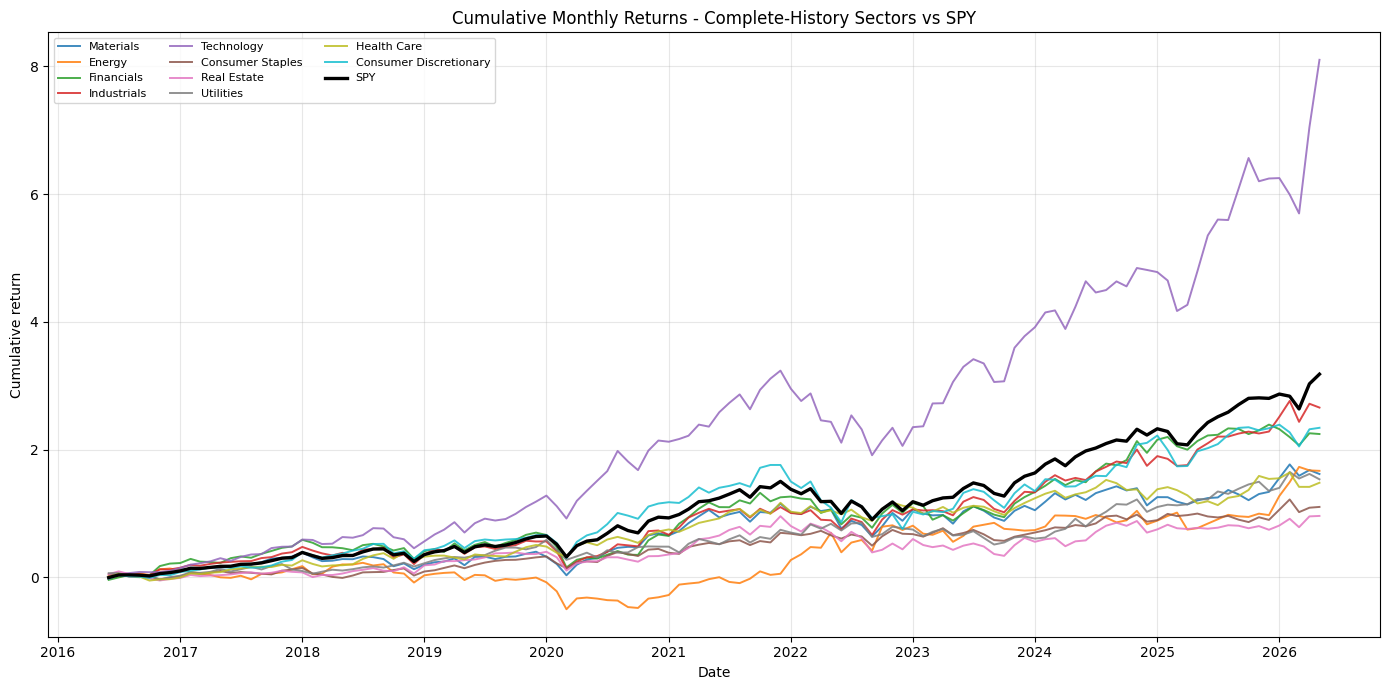

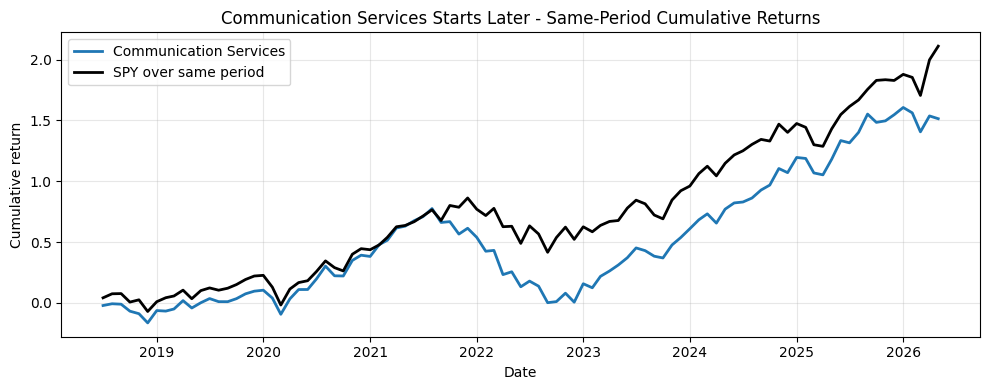

In [10]:
# Cumulative sector and SPY returns
cum_sector = (1 + sector_returns_aligned[full_sample_sectors]).cumprod() - 1
cum_spy = (1 + spy_returns_aligned["SPY"]).cumprod() - 1

fig, ax = plt.subplots(figsize=(14, 7))
for sector in full_sample_sectors:
    ax.plot(cum_sector.index, cum_sector[sector], linewidth=1.4, alpha=0.85, label=sector)
ax.plot(cum_spy.index, cum_spy, color="black", linewidth=2.4, label="SPY")
ax.set_title("Cumulative Monthly Returns - Complete-History Sectors vs SPY")
ax.set_ylabel("Cumulative return")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

# Communication Services starts later because XLC history is shorter.
if sector_returns_aligned["Communication Services"].notna().any():
    xlc_returns = sector_returns_aligned["Communication Services"].dropna()
    xlc_cum = (1 + xlc_returns).cumprod() - 1
    spy_same = (1 + spy_returns_aligned.loc[xlc_returns.index, "SPY"]).cumprod() - 1

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(xlc_cum.index, xlc_cum, label="Communication Services", linewidth=2)
    ax.plot(spy_same.index, spy_same, label="SPY over same period", color="black", linewidth=2)
    ax.set_title("Communication Services Starts Later - Same-Period Cumulative Returns")
    ax.set_ylabel("Cumulative return")
    ax.set_xlabel("Date")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


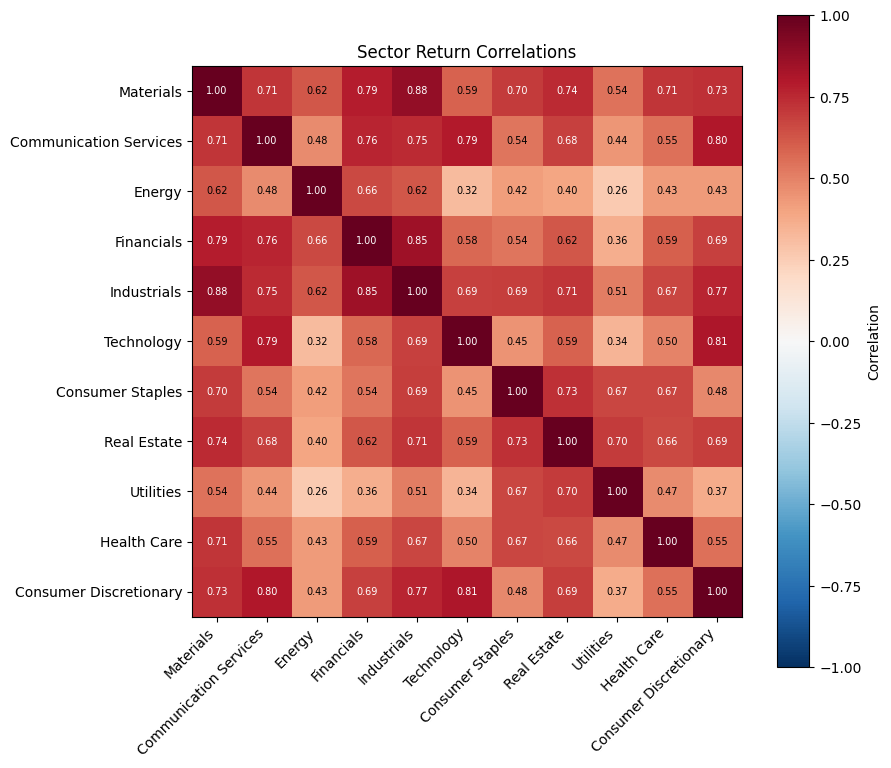

In [11]:
# Sector return correlation heatmap
sector_corr = sector_returns_aligned.corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(sector_corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(sector_corr.columns)))
ax.set_yticks(range(len(sector_corr.index)))
ax.set_xticklabels(sector_corr.columns, rotation=45, ha="right")
ax.set_yticklabels(sector_corr.index)
ax.set_title("Sector Return Correlations")

for i in range(len(sector_corr.index)):
    for j in range(len(sector_corr.columns)):
        val = sector_corr.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(val) > 0.65 else "black")

plt.colorbar(im, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()


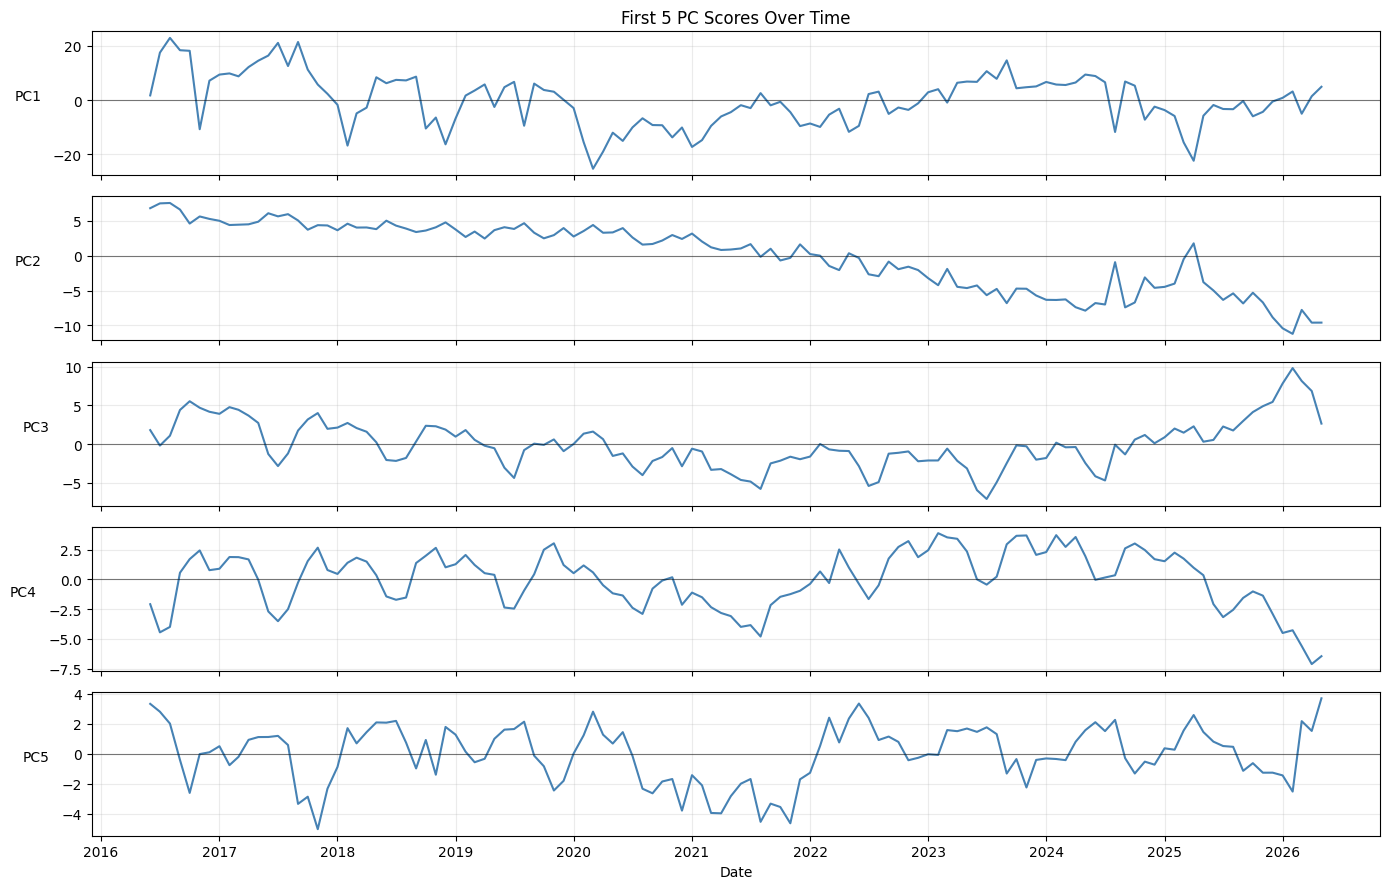

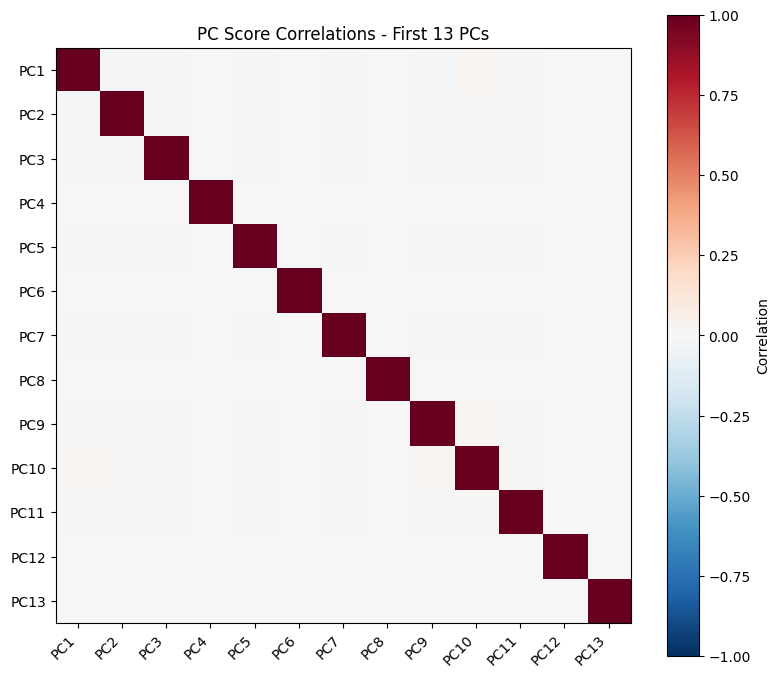

In [12]:
# First 13 PC score behavior
pc_subset = pca_scores_aligned[PC_DIAGNOSTIC_COLS]

fig, axes = plt.subplots(5, 1, figsize=(14, 9), sharex=True)
for ax, pc in zip(axes, PC_DIAGNOSTIC_COLS[:5]):
    ax.plot(pc_subset.index, pc_subset[pc], linewidth=1.5, color="steelblue")
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
    ax.set_ylabel(pc, rotation=0, labelpad=18)
    ax.grid(True, alpha=0.25)
axes[0].set_title("First 5 PC Scores Over Time")
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

pc_corr = pc_subset.corr()
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(pc_corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(pc_corr.columns)))
ax.set_yticks(range(len(pc_corr.index)))
ax.set_xticklabels(pc_corr.columns, rotation=45, ha="right")
ax.set_yticklabels(pc_corr.index)
ax.set_title("PC Score Correlations - First 13 PCs")
plt.colorbar(im, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()


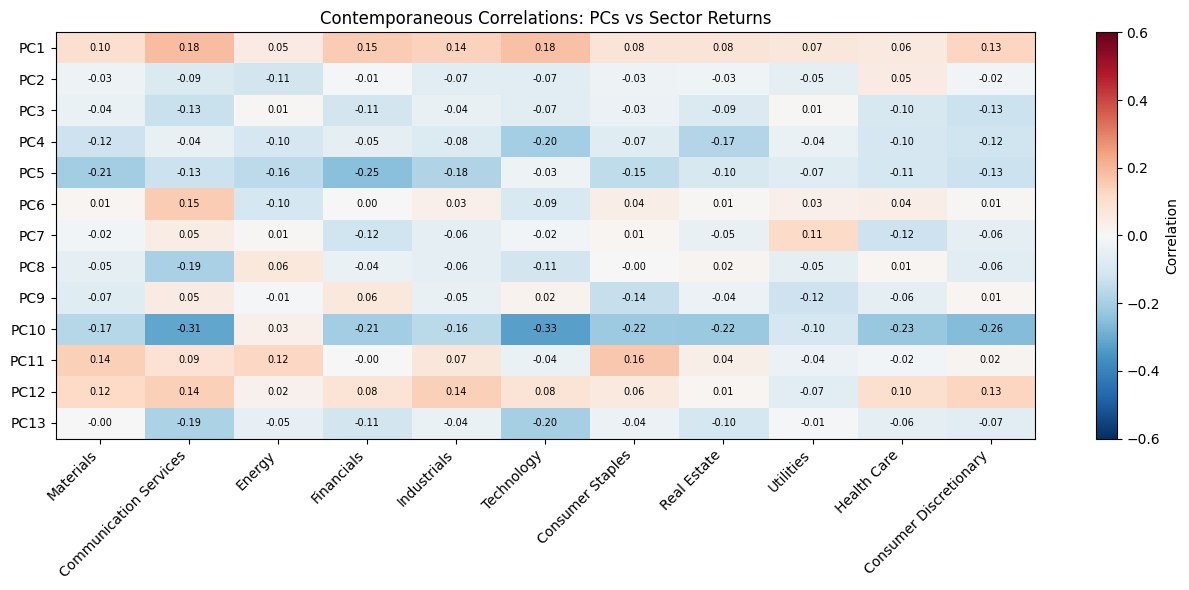

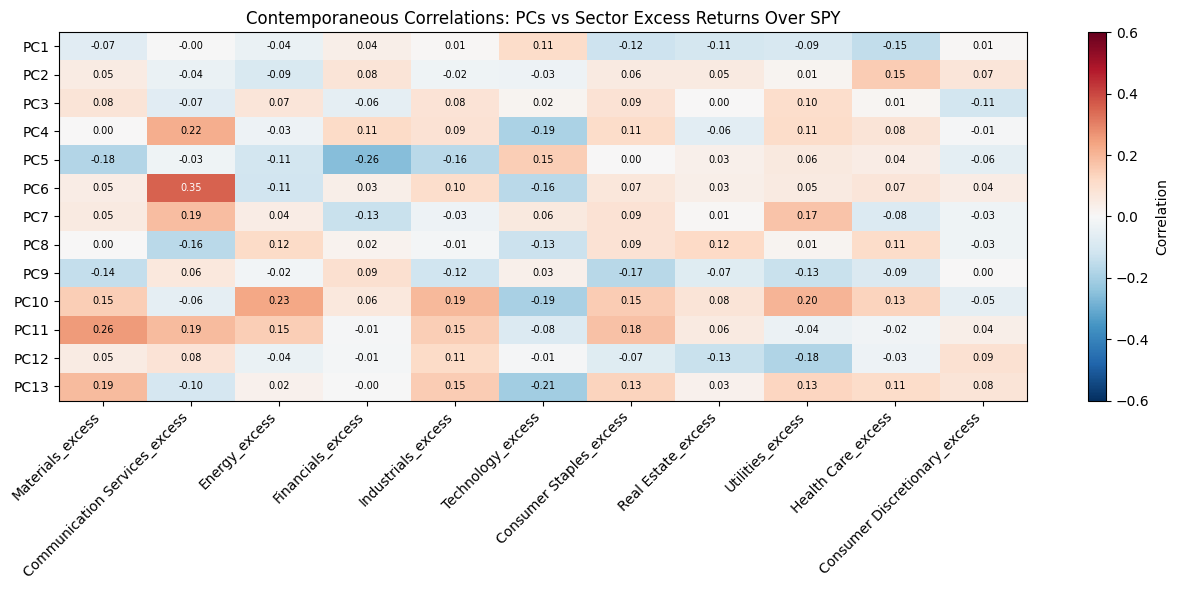

In [13]:
# Contemporaneous correlations between PCs and sector returns.
# These are diagnostics only, not predictive evidence.
def plot_pc_return_corr(return_df, title):
    corr = pd.DataFrame(index=PC_DIAGNOSTIC_COLS, columns=return_df.columns, dtype=float)
    for pc in PC_DIAGNOSTIC_COLS:
        for sector in return_df.columns:
            joined = pd.concat([pca_scores_aligned[pc], return_df[sector]], axis=1).dropna()
            corr.loc[pc, sector] = joined.iloc[:, 0].corr(joined.iloc[:, 1])

    fig, ax = plt.subplots(figsize=(13, 6))
    im = ax.imshow(corr.astype(float), cmap="RdBu_r", vmin=-0.6, vmax=0.6, aspect="auto")
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.index)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr.index)
    ax.set_title(title)

    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            val = corr.iloc[i, j]
            if pd.notna(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7,
                        color="white" if abs(val) > 0.35 else "black")

    plt.colorbar(im, ax=ax, label="Correlation")
    plt.tight_layout()
    plt.show()
    return corr

pc_sector_corr = plot_pc_return_corr(
    sector_returns_aligned,
    "Contemporaneous Correlations: PCs vs Sector Returns",
)

pc_excess_corr = plot_pc_return_corr(
    sector_excess_aligned,
    "Contemporaneous Correlations: PCs vs Sector Excess Returns Over SPY",
)


In [14]:
# Largest absolute contemporaneous PC/return correlations for quick inspection.
def top_abs_corr(corr_df, n=15):
    out = (
        corr_df.stack()
        .rename("corr")
        .reset_index()
        .rename(columns={"level_0": "PC", "level_1": "target"})
    )
    out["abs_corr"] = out["corr"].abs()
    return out.sort_values("abs_corr", ascending=False).head(n).drop(columns="abs_corr")

print("Top absolute PC/raw-sector correlations:")
display(top_abs_corr(pc_sector_corr, 15))

print("Top absolute PC/sector-excess correlations:")
display(top_abs_corr(pc_excess_corr, 15))


Top absolute PC/raw-sector correlations:


,PC,Ticker,corr
104,PC10,Technology,-0.326693
100,PC10,Communication Services,-0.312179
109,PC10,Consumer Discretionary,-0.260059
47,PC5,Financials,-0.250530
108,PC10,Health Care,-0.225012
106,PC10,Real Estate,-0.224678
105,PC10,Consumer Staples,-0.219519
44,PC5,Materials,-0.209100
102,PC10,Financials,-0.207256
38,PC4,Technology,-0.203123


Top absolute PC/sector-excess correlations:


,PC,target,corr
56,PC6,Communication Services_excess,0.353813
47,PC5,Financials_excess,-0.256885
110,PC11,Materials_excess,0.255176
101,PC10,Energy_excess,0.230521
34,PC4,Communication Services_excess,0.215800
137,PC13,Technology_excess,-0.209471
107,PC10,Utilities_excess,0.204604
104,PC10,Technology_excess,-0.193487
103,PC10,Industrials_excess,0.192678
111,PC11,Communication Services_excess,0.191671


## 3. Granger / VAR Directional Tests

These tests ask whether lagged attention factors improve forecasts of sector returns beyond lagged sector returns. This is Granger-style predictive causality, not true economic causality. We also run the reverse direction to see whether sector returns appear to lead the attention factors.


In [15]:
from scipy import stats

# Granger-style joint F-test implemented directly with OLS.
# Restricted model: y_t ~ const + lags(y)
# Unrestricted model: y_t ~ const + lags(y) + lags(X block)
def _lagged_columns(values, lags, prefix):
    cols = []
    names = []
    for lag in range(1, lags + 1):
        cols.append(values.shift(lag))
        names.extend([f"{prefix}_lag{lag}_{col}" for col in values.columns])
    out = pd.concat(cols, axis=1)
    out.columns = names
    return out


def _ols_rss(y, X):
    X_arr = np.asarray(X, dtype=float)
    y_arr = np.asarray(y, dtype=float)
    beta, *_ = np.linalg.lstsq(X_arr, y_arr, rcond=None)
    resid = y_arr - X_arr @ beta
    return float(resid @ resid), len(y_arr), X_arr.shape[1]


def granger_block_test(y, x_block, lags=1):
    y = y.rename("y").astype(float)
    x_block = x_block.astype(float)

    y_lags = _lagged_columns(y.to_frame(), lags, "y")
    x_lags = _lagged_columns(x_block, lags, "x")

    data = pd.concat([y, y_lags, x_lags], axis=1).dropna()
    if data.empty:
        return {"F": np.nan, "pvalue": np.nan, "nobs": 0, "df_num": np.nan, "df_den": np.nan}

    y_dep = data["y"]
    X_restricted = pd.concat([
        pd.Series(1.0, index=data.index, name="const"),
        data[y_lags.columns],
    ], axis=1)
    X_unrestricted = pd.concat([X_restricted, data[x_lags.columns]], axis=1)

    rss_r, nobs, k_r = _ols_rss(y_dep, X_restricted)
    rss_u, _, k_u = _ols_rss(y_dep, X_unrestricted)

    q = k_u - k_r
    df_den = nobs - k_u
    if q <= 0 or df_den <= 0 or rss_u <= 0:
        return {"F": np.nan, "pvalue": np.nan, "nobs": nobs, "df_num": q, "df_den": df_den}

    F = ((rss_r - rss_u) / q) / (rss_u / df_den)
    pvalue = stats.f.sf(F, q, df_den)
    return {"F": F, "pvalue": pvalue, "nobs": nobs, "df_num": q, "df_den": df_den}


In [16]:
# Run PC -> sector-return Granger-style tests.
GRANGER_PC_COUNTS = [5, 10, 13]
GRANGER_LAGS = [1, 2]

def run_pc_to_targets(target_df, target_type):
    rows = []
    for pc_count in GRANGER_PC_COUNTS:
        pc_cols = [f"PC{i}" for i in range(1, pc_count + 1)]
        x_block = pca_scores_aligned[pc_cols]
        for lags in GRANGER_LAGS:
            for target in target_df.columns:
                y = target_df[target]
                result = granger_block_test(y, x_block, lags=lags)
                rows.append({
                    "direction": "PCs -> target",
                    "target_type": target_type,
                    "target": target,
                    "pc_count": pc_count,
                    "lags": lags,
                    **result,
                })
    return pd.DataFrame(rows)

raw_granger = run_pc_to_targets(sector_returns_aligned, "raw_sector_return")
excess_granger = run_pc_to_targets(sector_excess_aligned, "sector_excess_return")
pc_to_sector_granger = pd.concat([raw_granger, excess_granger], ignore_index=True)

print("Smallest p-values for PC -> sector/sector-excess tests:")
pc_to_sector_granger.sort_values("pvalue").head(20)


Smallest p-values for PC -> sector/sector-excess tests:


,direction,target_type,target,pc_count,lags,F,pvalue,nobs,df_num,df_den
111,PCs -> target,sector_excess_return,Communication Services_excess,13,1,2.926163,0.001639,94,13,79
56,PCs -> target,raw_sector_return,Communication Services,13,2,2.074166,0.009476,93,26,64
34,PCs -> target,raw_sector_return,Communication Services,10,2,2.019537,0.016516,93,20,70
89,PCs -> target,sector_excess_return,Communication Services_excess,10,1,2.287822,0.020196,94,10,82
122,PCs -> target,sector_excess_return,Communication Services_excess,13,2,1.723404,0.040299,93,26,64
45,PCs -> target,raw_sector_return,Communication Services,13,1,1.866600,0.047010,94,13,79
82,PCs -> target,sector_excess_return,Technology_excess,5,2,1.931871,0.048684,118,10,105
100,PCs -> target,sector_excess_return,Communication Services_excess,10,2,1.720138,0.050398,93,20,70
58,PCs -> target,raw_sector_return,Financials,13,2,1.586971,0.057763,118,26,89
91,PCs -> target,sector_excess_return,Financials_excess,10,1,1.837130,0.062590,119,10,107


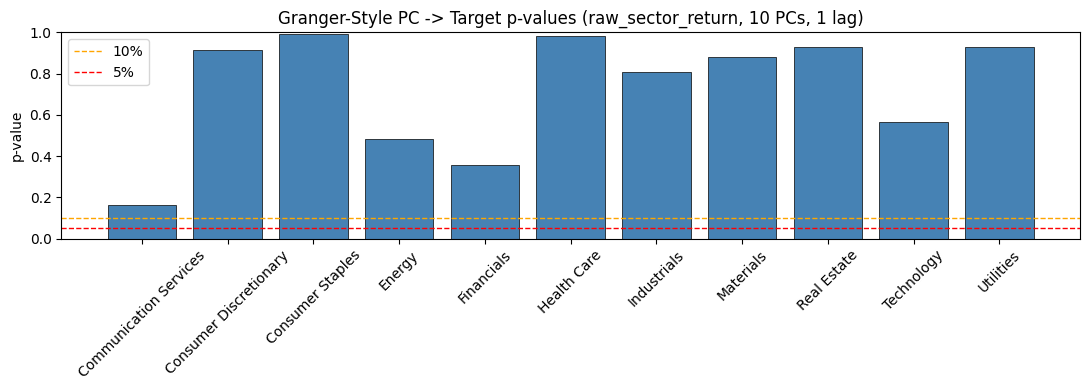

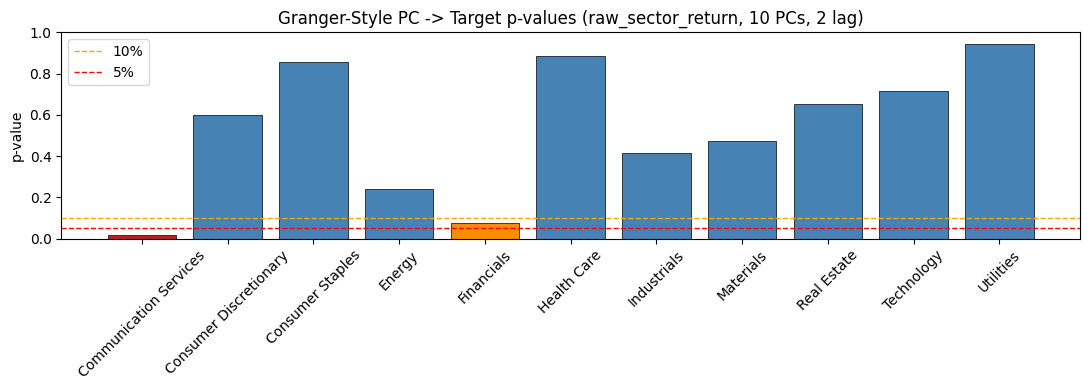

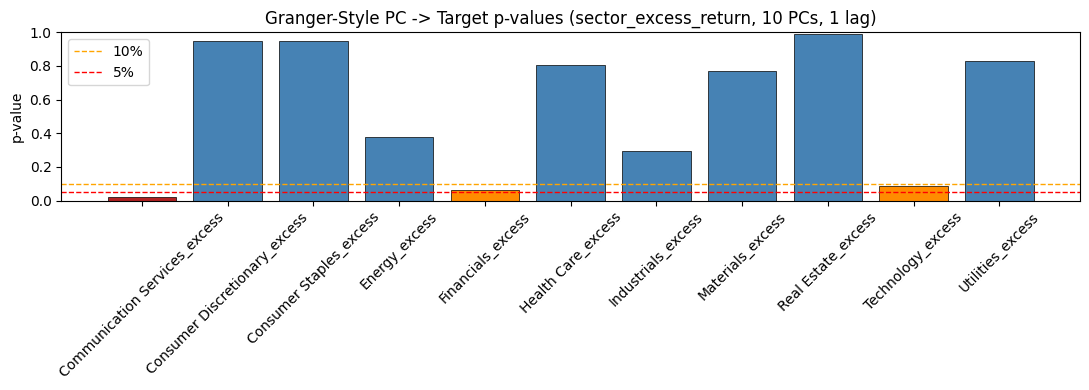

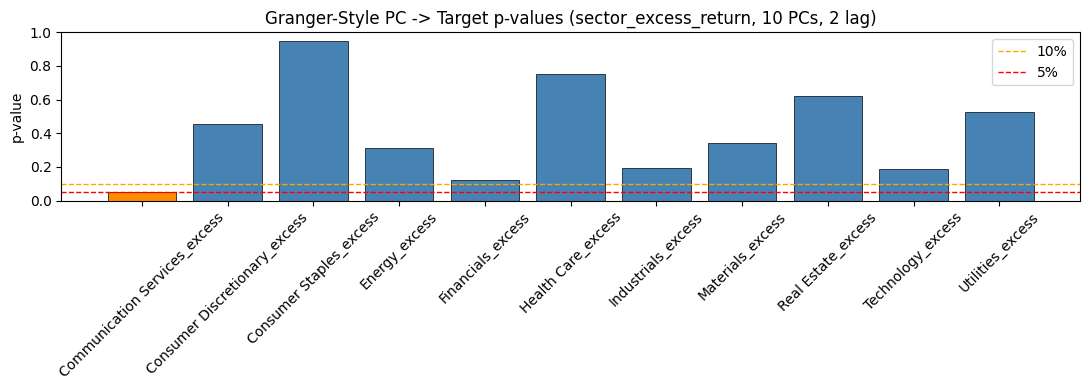

In [17]:
# Visualize p-values for the main 10-PC specification.
def plot_granger_pvalues(results, target_type, pc_count=10, lags=1):
    subset = results[
        (results["target_type"] == target_type)
        & (results["pc_count"] == pc_count)
        & (results["lags"] == lags)
    ].copy()
    subset = subset.sort_values("target")
    pvals = subset.set_index("target")["pvalue"]

    fig, ax = plt.subplots(figsize=(11, 4))
    colors = np.where(pvals < 0.05, "firebrick", np.where(pvals < 0.10, "darkorange", "steelblue"))
    ax.bar(pvals.index, pvals.values, color=colors, edgecolor="black", linewidth=0.5)
    ax.axhline(0.10, color="orange", linestyle="--", linewidth=1, label="10%")
    ax.axhline(0.05, color="red", linestyle="--", linewidth=1, label="5%")
    ax.set_title(f"Granger-Style PC -> Target p-values ({target_type}, {pc_count} PCs, {lags} lag)")
    ax.set_ylabel("p-value")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
    plt.tight_layout()
    plt.show()

for target_type in ["raw_sector_return", "sector_excess_return"]:
    for lag in GRANGER_LAGS:
        plot_granger_pvalues(pc_to_sector_granger, target_type, pc_count=10, lags=lag)


In [18]:
# Reverse direction: do sector returns Granger-predict individual PCs?
# Use complete-history sectors to avoid XLC-driven missing values in the sector block.
complete_sector_block = sector_returns_aligned[full_sample_sectors]

reverse_rows = []
for lags in GRANGER_LAGS:
    for pc in PC_DIAGNOSTIC_COLS:
        result = granger_block_test(pca_scores_aligned[pc], complete_sector_block, lags=lags)
        reverse_rows.append({
            "direction": "complete sectors -> PC",
            "target": pc,
            "lags": lags,
            **result,
        })

sector_to_pc_granger = pd.DataFrame(reverse_rows)
print("Smallest p-values for complete-sector block -> PC tests:")
sector_to_pc_granger.sort_values("pvalue").head(15)


Smallest p-values for complete-sector block -> PC tests:


,direction,target,lags,F,pvalue,nobs,df_num,df_den
18,complete sectors -> PC,PC6,2,2.149485,0.007348,118,20,95
24,complete sectors -> PC,PC12,2,1.684657,0.049495,118,20,95
12,complete sectors -> PC,PC13,1,1.795629,0.069920,119,10,107
25,complete sectors -> PC,PC13,2,1.499279,0.099617,118,20,95
19,complete sectors -> PC,PC7,2,1.322645,0.184279,118,20,95
15,complete sectors -> PC,PC3,2,1.291689,0.203950,118,20,95
5,complete sectors -> PC,PC6,1,1.356621,0.210505,119,10,107
14,complete sectors -> PC,PC2,2,1.241377,0.239389,118,20,95
6,complete sectors -> PC,PC7,1,1.295915,0.242040,119,10,107
9,complete sectors -> PC,PC10,1,1.098870,0.369749,119,10,107


In [19]:
# SPY direction checks: PCs -> SPY and SPY -> PCs.
spy_direction_rows = []
for pc_count in GRANGER_PC_COUNTS:
    pc_cols = [f"PC{i}" for i in range(1, pc_count + 1)]
    for lags in GRANGER_LAGS:
        result = granger_block_test(spy_returns_aligned["SPY"], pca_scores_aligned[pc_cols], lags=lags)
        spy_direction_rows.append({
            "direction": "PCs -> SPY",
            "target": "SPY",
            "pc_count": pc_count,
            "lags": lags,
            **result,
        })

for lags in GRANGER_LAGS:
    for pc in PC_DIAGNOSTIC_COLS:
        result = granger_block_test(pca_scores_aligned[pc], spy_returns_aligned[["SPY"]], lags=lags)
        spy_direction_rows.append({
            "direction": "SPY -> PC",
            "target": pc,
            "pc_count": 1,
            "lags": lags,
            **result,
        })

spy_granger = pd.DataFrame(spy_direction_rows)
spy_granger.sort_values("pvalue").head(20)


,direction,target,pc_count,lags,F,pvalue,nobs,df_num,df_den
24,SPY -> PC,PC6,1,2,5.347024,0.006043,118,2,113
21,SPY -> PC,PC3,1,2,4.222673,0.017038,118,2,113
11,SPY -> PC,PC6,1,1,3.537974,0.062486,119,1,116
20,SPY -> PC,PC2,1,2,2.247105,0.110408,118,2,113
10,SPY -> PC,PC5,1,1,2.304597,0.131713,119,1,116
19,SPY -> PC,PC1,1,2,1.822547,0.166332,118,2,113
13,SPY -> PC,PC8,1,1,1.794016,0.183056,119,1,116
25,SPY -> PC,PC7,1,2,1.683628,0.190323,118,2,113
8,SPY -> PC,PC3,1,1,1.456433,0.229954,119,1,116
23,SPY -> PC,PC5,1,2,1.227523,0.296894,118,2,113


In [20]:
# Save Granger-style diagnostic results.
pc_to_sector_granger.to_csv(RESULTS_DATA_DIR / "granger_pc_to_sector_results.csv", index=False)
sector_to_pc_granger.to_csv(RESULTS_DATA_DIR / "granger_sector_to_pc_results.csv", index=False)
spy_granger.to_csv(RESULTS_DATA_DIR / "granger_spy_direction_results.csv", index=False)

print("Saved Granger-style diagnostic files:")
print("  granger_pc_to_sector_results.csv")
print("  granger_sector_to_pc_results.csv")
print("  granger_spy_direction_results.csv")


Saved Granger-style diagnostic files:
  granger_pc_to_sector_results.csv
  granger_sector_to_pc_results.csv
  granger_spy_direction_results.csv


### Granger P-Value Heatmaps

Heatmaps summarize the Granger-style p-values by sector for the main 10-PC specification. Blue cells indicate lower p-values / stronger predictive evidence. Stars denote conventional significance levels.


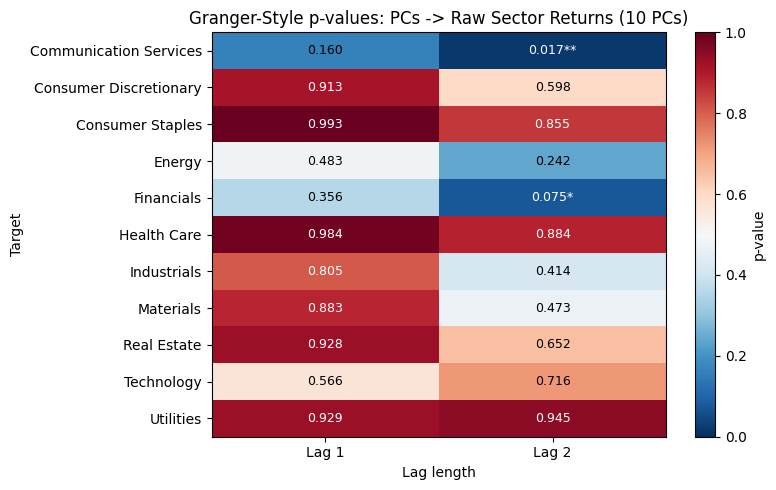

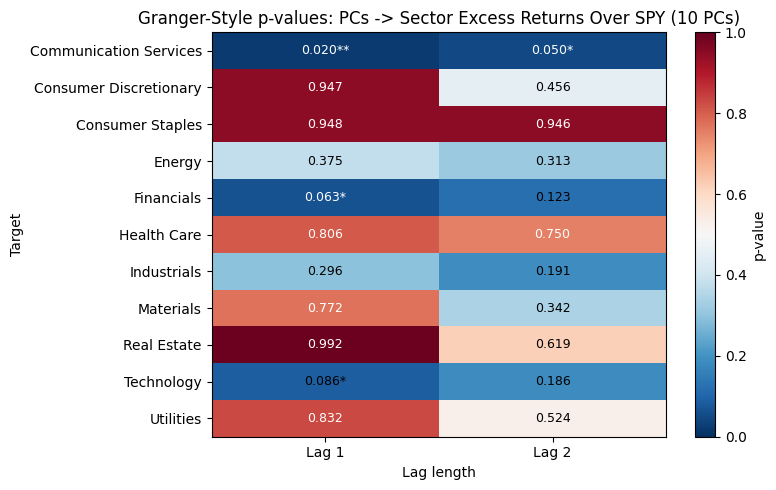

In [21]:
def _pvalue_label(p):
    if pd.isna(p):
        return ""
    stars = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""
    return f"{p:.3f}{stars}"


def plot_granger_pvalue_heatmap(results, target_type, pc_count=10, title=None):
    subset = results[
        (results["target_type"] == target_type)
        & (results["pc_count"] == pc_count)
    ].copy()

    heat = subset.pivot(index="target", columns="lags", values="pvalue")
    heat = heat.reindex(columns=sorted(heat.columns))

    # For excess-return labels, strip the suffix so raw/excess heatmaps align visually.
    display_index = [idx.replace("_excess", "") for idx in heat.index]

    fig, ax = plt.subplots(figsize=(8, max(5, 0.42 * len(heat))))
    im = ax.imshow(heat.values.astype(float), cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")

    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels([f"Lag {lag}" for lag in heat.columns])
    ax.set_yticks(range(len(heat.index)))
    ax.set_yticklabels(display_index)
    ax.set_title(title or f"Granger p-values: PCs -> {target_type} ({pc_count} PCs)")
    ax.set_xlabel("Lag length")
    ax.set_ylabel("Target")

    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            p = heat.iloc[i, j]
            text_color = "white" if (pd.notna(p) and (p < 0.08 or p > 0.75)) else "black"
            ax.text(j, i, _pvalue_label(p), ha="center", va="center", fontsize=9, color=text_color)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("p-value")
    plt.tight_layout()
    plt.show()

    return heat

raw_granger_heatmap_10pc = plot_granger_pvalue_heatmap(
    pc_to_sector_granger,
    target_type="raw_sector_return",
    pc_count=10,
    title="Granger-Style p-values: PCs -> Raw Sector Returns (10 PCs)",
)

excess_granger_heatmap_10pc = plot_granger_pvalue_heatmap(
    pc_to_sector_granger,
    target_type="sector_excess_return",
    pc_count=10,
    title="Granger-Style p-values: PCs -> Sector Excess Returns Over SPY (10 PCs)",
)


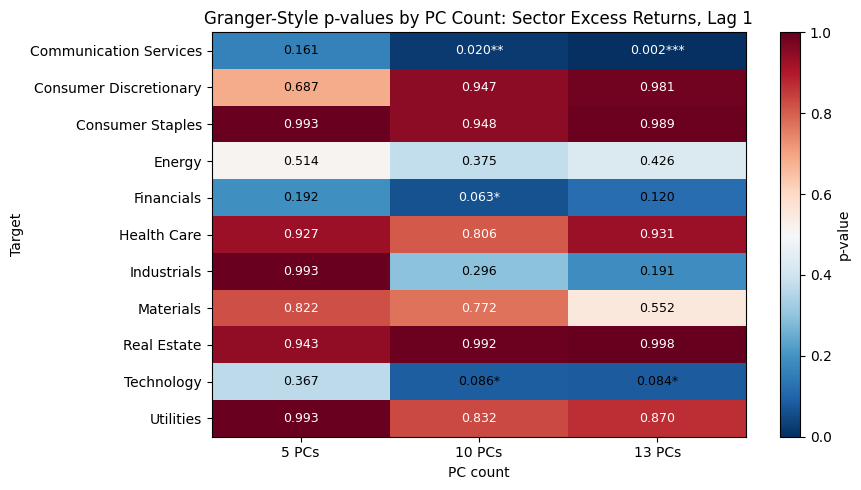

In [22]:
# Optional companion: compare the 5/10/13 PC specifications at lag 1 for excess returns.
def plot_pc_count_comparison_heatmap(results, target_type, lag=1, title=None):
    subset = results[
        (results["target_type"] == target_type)
        & (results["lags"] == lag)
    ].copy()
    heat = subset.pivot(index="target", columns="pc_count", values="pvalue")
    heat = heat.reindex(columns=GRANGER_PC_COUNTS)
    display_index = [idx.replace("_excess", "") for idx in heat.index]

    fig, ax = plt.subplots(figsize=(9, max(5, 0.42 * len(heat))))
    im = ax.imshow(heat.values.astype(float), cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels([f"{n} PCs" for n in heat.columns])
    ax.set_yticks(range(len(heat.index)))
    ax.set_yticklabels(display_index)
    ax.set_title(title or f"Granger p-values by PC count ({target_type}, lag {lag})")
    ax.set_xlabel("PC count")
    ax.set_ylabel("Target")

    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            p = heat.iloc[i, j]
            text_color = "white" if (pd.notna(p) and (p < 0.08 or p > 0.75)) else "black"
            ax.text(j, i, _pvalue_label(p), ha="center", va="center", fontsize=9, color=text_color)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("p-value")
    plt.tight_layout()
    plt.show()
    return heat

excess_pc_count_lag1_heatmap = plot_pc_count_comparison_heatmap(
    pc_to_sector_granger,
    target_type="sector_excess_return",
    lag=1,
    title="Granger-Style p-values by PC Count: Sector Excess Returns, Lag 1",
)


### Directional Search-Return Causality Visuals

These figures are designed to answer the direction question more directly: do Google-search attention factors lead sector returns, or do sector/market returns lead search attention? Blue means lower p-values / stronger Granger-style evidence. For the reverse direction, each sector is tested against individual PCs and the heatmap reports the strongest sector -> PC relationship among the first 10 PCs, with the PC label shown in the cell.


In [23]:
# Build sector-by-sector directional p-value summaries.
DIRECTIONAL_PC_COUNT = 10
DIRECTIONAL_PC_COLS = [f"PC{i}" for i in range(1, DIRECTIONAL_PC_COUNT + 1)]
DIRECTIONAL_LAGS = [1, 2]


def strongest_target_to_pc(target_series, target_name, target_type, lags):
    rows = []
    for pc in DIRECTIONAL_PC_COLS:
        result = granger_block_test(pca_scores_aligned[pc], target_series.to_frame(target_name), lags=lags)
        rows.append({
            "target_type": target_type,
            "target": target_name,
            "pc": pc,
            "lags": lags,
            **result,
        })
    df = pd.DataFrame(rows).sort_values("pvalue")
    return df.iloc[0].to_dict()

reverse_sector_pc_rows = []
for lags in DIRECTIONAL_LAGS:
    for sector in sector_returns_aligned.columns:
        reverse_sector_pc_rows.append(
            strongest_target_to_pc(sector_returns_aligned[sector], sector, "raw_sector_return", lags)
        )
    for sector_excess in sector_excess_aligned.columns:
        reverse_sector_pc_rows.append(
            strongest_target_to_pc(sector_excess_aligned[sector_excess], sector_excess, "sector_excess_return", lags)
        )

reverse_sector_to_pc_best = pd.DataFrame(reverse_sector_pc_rows)
reverse_sector_to_pc_best.head()


,target_type,target,pc,lags,F,pvalue,nobs,df_num,df_den
0,raw_sector_return,Materials,PC7,1,1.876507,0.173377,119,1,116
1,raw_sector_return,Communication Services,PC6,1,4.389281,0.038944,94,1,91
2,raw_sector_return,Energy,PC8,1,1.067716,0.303611,119,1,116
3,raw_sector_return,Financials,PC6,1,2.782316,0.098008,119,1,116
4,raw_sector_return,Industrials,PC8,1,2.246968,0.136593,119,1,116


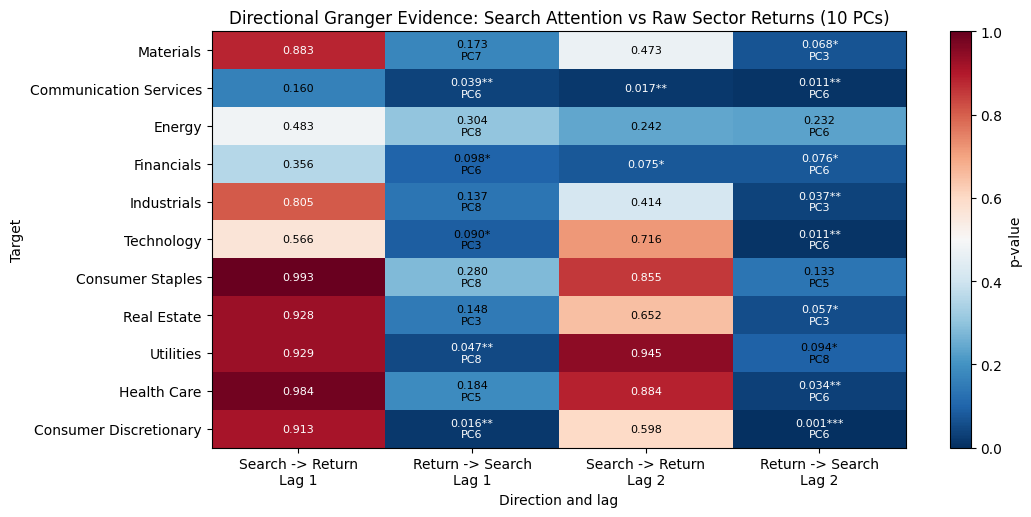

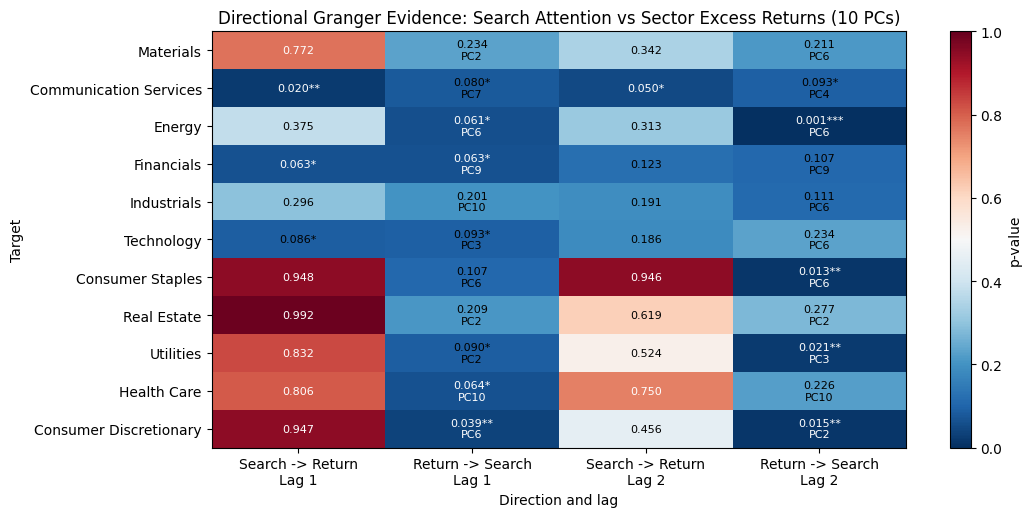

In [24]:
def _directional_label(p, pc=None):
    if pd.isna(p):
        return ""
    stars = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""
    if pc is None:
        return f"{p:.3f}{stars}"
    return f"{p:.3f}{stars}\n{pc}"


def directional_causality_heatmap(target_type, pc_count=10, title=None):
    forward = pc_to_sector_granger[
        (pc_to_sector_granger["target_type"] == target_type)
        & (pc_to_sector_granger["pc_count"] == pc_count)
        & (pc_to_sector_granger["lags"].isin(DIRECTIONAL_LAGS))
    ].copy()
    reverse = reverse_sector_to_pc_best[
        (reverse_sector_to_pc_best["target_type"] == target_type)
        & (reverse_sector_to_pc_best["lags"].isin(DIRECTIONAL_LAGS))
    ].copy()

    targets = forward["target"].tolist()
    targets = list(dict.fromkeys(targets))
    display_targets = [target.replace("_excess", "") for target in targets]

    columns = []
    values = []
    labels = []
    for lag in DIRECTIONAL_LAGS:
        columns.append(f"Search -> Return\nLag {lag}")
        fwd = forward[forward["lags"] == lag].set_index("target").reindex(targets)
        values.append(fwd["pvalue"].to_numpy())
        labels.append([_directional_label(p) for p in fwd["pvalue"]])

        columns.append(f"Return -> Search\nLag {lag}")
        rev = reverse[reverse["lags"] == lag].set_index("target").reindex(targets)
        values.append(rev["pvalue"].to_numpy())
        labels.append([_directional_label(p, pc) for p, pc in zip(rev["pvalue"], rev["pc"])])

    heat = np.column_stack(values)
    label_arr = np.array(labels).T

    fig, ax = plt.subplots(figsize=(11, max(5, 0.48 * len(targets))))
    im = ax.imshow(heat.astype(float), cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")

    ax.set_xticks(range(len(columns)))
    ax.set_xticklabels(columns)
    ax.set_yticks(range(len(targets)))
    ax.set_yticklabels(display_targets)
    ax.set_title(title or f"Directional Granger-Style p-values ({target_type}, {pc_count} PCs)")
    ax.set_xlabel("Direction and lag")
    ax.set_ylabel("Target")

    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            p = heat[i, j]
            text_color = "white" if pd.notna(p) and (p < 0.08 or p > 0.75) else "black"
            ax.text(j, i, label_arr[i, j], ha="center", va="center", fontsize=8, color=text_color)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("p-value")
    plt.tight_layout()
    plt.show()

    out = pd.DataFrame(heat, index=targets, columns=columns)
    return out

raw_directional_heatmap = directional_causality_heatmap(
    "raw_sector_return",
    pc_count=10,
    title="Directional Granger Evidence: Search Attention vs Raw Sector Returns (10 PCs)",
)

excess_directional_heatmap = directional_causality_heatmap(
    "sector_excess_return",
    pc_count=10,
    title="Directional Granger Evidence: Search Attention vs Sector Excess Returns (10 PCs)",
)


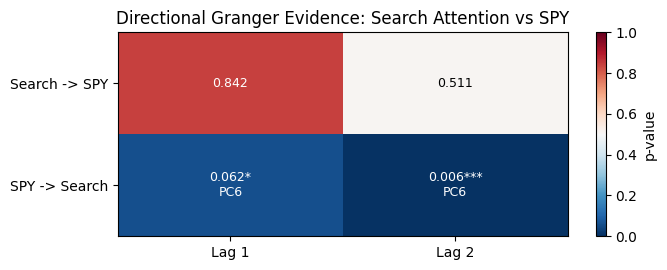

,direction,lags,pc,F,pvalue,nobs,df_num,df_den,target_type,target
0,Search -> SPY,1,None,0.561711,0.841665,119,10,107,NaN,NaN
1,SPY -> Search,1,PC6,3.537974,0.062486,119,1,116,market_return,SPY
2,Search -> SPY,2,None,0.964176,0.511140,118,20,95,NaN,NaN
3,SPY -> Search,2,PC6,5.347024,0.006043,118,2,113,market_return,SPY


In [25]:
# SPY directional companion: does broad market movement lead searches, or do searches lead SPY?
spy_rows = []
for lag in DIRECTIONAL_LAGS:
    fwd = granger_block_test(spy_returns_aligned["SPY"], pca_scores_aligned[DIRECTIONAL_PC_COLS], lags=lag)
    spy_rows.append({"direction": "Search -> SPY", "lags": lag, "pc": None, **fwd})

    best_reverse = strongest_target_to_pc(spy_returns_aligned["SPY"], "SPY", "market_return", lag)
    spy_rows.append({"direction": "SPY -> Search", **best_reverse})

spy_directional_summary = pd.DataFrame(spy_rows)

fig, ax = plt.subplots(figsize=(7, 2.8))
heat = spy_directional_summary.pivot(index="direction", columns="lags", values="pvalue")
label_pcs = spy_directional_summary.pivot(index="direction", columns="lags", values="pc")
heat = heat.reindex(["Search -> SPY", "SPY -> Search"])
label_pcs = label_pcs.reindex(heat.index)

im = ax.imshow(heat.values.astype(float), cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels([f"Lag {lag}" for lag in heat.columns])
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_title("Directional Granger Evidence: Search Attention vs SPY")

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        p = heat.iloc[i, j]
        pc = label_pcs.iloc[i, j]
        label = _directional_label(p, None if pd.isna(pc) else pc)
        text_color = "white" if pd.notna(p) and (p < 0.08 or p > 0.75) else "black"
        ax.text(j, i, label, ha="center", va="center", fontsize=9, color=text_color)

plt.colorbar(im, ax=ax, label="p-value")
plt.tight_layout()
plt.show()

spy_directional_summary


In [26]:
# Save directional summaries.
reverse_sector_to_pc_best.to_csv(RESULTS_DATA_DIR / "granger_sector_to_pc_best_by_sector.csv", index=False)
raw_directional_heatmap.to_csv(RESULTS_DATA_DIR / "granger_directional_raw_heatmap.csv")
excess_directional_heatmap.to_csv(RESULTS_DATA_DIR / "granger_directional_excess_heatmap.csv")
spy_directional_summary.to_csv(RESULTS_DATA_DIR / "granger_directional_spy_summary.csv", index=False)

print("Saved directional Granger summary files:")
print("  granger_sector_to_pc_best_by_sector.csv")
print("  granger_directional_raw_heatmap.csv")
print("  granger_directional_excess_heatmap.csv")
print("  granger_directional_spy_summary.csv")


Saved directional Granger summary files:
  granger_sector_to_pc_best_by_sector.csv
  granger_directional_raw_heatmap.csv
  granger_directional_excess_heatmap.csv
  granger_directional_spy_summary.csv


## 4. In-Sample Predictive Regressions

This section tests whether lagged PCA attention factors explain future sector returns in-sample. We run OLS, Ridge, Lasso, and Elastic Net for PC counts of 5, 10, and 13, horizons `t+1` and `t+2`, and both raw sector returns and sector excess returns over SPY.


In [27]:
# In-sample model helpers
try:
    from sklearn.linear_model import ElasticNetCV, LassoCV, RidgeCV
    from sklearn.model_selection import TimeSeriesSplit
    from sklearn.preprocessing import StandardScaler as SklearnStandardScaler
    SKLEARN_AVAILABLE = True
    print("Using scikit-learn for Ridge/Lasso/ElasticNet")
except ModuleNotFoundError:
    SKLEARN_AVAILABLE = False
    print("scikit-learn not found in this kernel; using local NumPy implementations")


def standardize_train_full(X):
    X = np.asarray(X, dtype=float)
    mean = X.mean(axis=0)
    scale = X.std(axis=0, ddof=0)
    scale[scale == 0] = 1.0
    return (X - mean) / scale, mean, scale


def add_const(X):
    return np.column_stack([np.ones(len(X)), X])


def r2_score_np(y, pred):
    y = np.asarray(y, dtype=float)
    pred = np.asarray(pred, dtype=float)
    ss_res = np.sum((y - pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return np.nan if ss_tot == 0 else 1 - ss_res / ss_tot


def adjusted_r2(r2, nobs, n_predictors):
    if nobs <= n_predictors + 1 or pd.isna(r2):
        return np.nan
    return 1 - (1 - r2) * (nobs - 1) / (nobs - n_predictors - 1)


def fit_ols_np(X, y):
    Xc = add_const(X)
    coef, *_ = np.linalg.lstsq(Xc, y, rcond=None)
    pred = Xc @ coef
    return pred, coef[0], coef[1:]


def fit_ridge_np(X, y, alpha):
    Xc = add_const(X)
    penalty = np.eye(Xc.shape[1])
    penalty[0, 0] = 0.0
    coef = np.linalg.solve(Xc.T @ Xc + alpha * penalty, Xc.T @ y)
    pred = Xc @ coef
    return pred, coef[0], coef[1:]


def soft_threshold(value, penalty):
    if value > penalty:
        return value - penalty
    if value < -penalty:
        return value + penalty
    return 0.0


def fit_elastic_net_cd(X, y, alpha, l1_ratio=1.0, max_iter=5000, tol=1e-7):
    # X should be standardized. y is centered internally; intercept is added back at the end.
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    y_mean = y.mean()
    yc = y - y_mean
    n, p = X.shape
    beta = np.zeros(p)
    col_norm = (X ** 2).mean(axis=0)
    l1 = alpha * l1_ratio
    l2 = alpha * (1 - l1_ratio)

    for _ in range(max_iter):
        beta_old = beta.copy()
        for j in range(p):
            residual = yc - X @ beta + X[:, j] * beta[j]
            rho = (X[:, j] @ residual) / n
            beta[j] = soft_threshold(rho, l1) / (col_norm[j] + l2)
        if np.max(np.abs(beta - beta_old)) < tol:
            break

    intercept = y_mean
    pred = intercept + X @ beta
    return pred, intercept, beta


def time_series_cv_splits(nobs, n_splits=5):
    n_splits = min(n_splits, max(2, nobs // 15))
    fold_size = nobs // (n_splits + 1)
    splits = []
    for i in range(1, n_splits + 1):
        train_end = fold_size * i
        test_end = fold_size * (i + 1) if i < n_splits else nobs
        if train_end > 10 and test_end > train_end:
            splits.append((np.arange(train_end), np.arange(train_end, test_end)))
    return splits


def choose_regularization_np(X, y, model_name, alpha_grid, l1_ratio_grid=None):
    splits = time_series_cv_splits(len(y), n_splits=5)
    if not splits:
        return {"alpha": alpha_grid[len(alpha_grid)//2], "l1_ratio": 1.0 if model_name == "Lasso" else 0.5}

    best = {"mse": np.inf, "alpha": None, "l1_ratio": None}
    ratios = l1_ratio_grid if l1_ratio_grid is not None else [1.0]

    for alpha in alpha_grid:
        for l1_ratio in ratios:
            mses = []
            for train_idx, test_idx in splits:
                X_train = X[train_idx]
                X_test = X[test_idx]
                y_train = y[train_idx]
                y_test = y[test_idx]

                mu = X_train.mean(axis=0)
                sig = X_train.std(axis=0, ddof=0)
                sig[sig == 0] = 1.0
                X_train_s = (X_train - mu) / sig
                X_test_s = (X_test - mu) / sig

                if model_name == "Ridge":
                    _, intercept, beta = fit_ridge_np(X_train_s, y_train, alpha)
                    pred = intercept + X_test_s @ beta
                elif model_name == "Lasso":
                    _, intercept, beta = fit_elastic_net_cd(X_train_s, y_train, alpha, l1_ratio=1.0)
                    pred = intercept + X_test_s @ beta
                else:
                    _, intercept, beta = fit_elastic_net_cd(X_train_s, y_train, alpha, l1_ratio=l1_ratio)
                    pred = intercept + X_test_s @ beta
                mses.append(np.mean((y_test - pred) ** 2))

            avg_mse = float(np.mean(mses))
            if avg_mse < best["mse"]:
                best = {"mse": avg_mse, "alpha": alpha, "l1_ratio": l1_ratio}
    return best


scikit-learn not found in this kernel; using local NumPy implementations


In [28]:
def make_predictive_dataset(pc_df, target_df, pc_count, horizon):
    pc_cols = [f"PC{i}" for i in range(1, pc_count + 1)]
    X = pc_df[pc_cols].copy()
    y = target_df.shift(-horizon).copy()
    data = X.join(y, how="inner").dropna()
    return data[pc_cols], data[target_df.columns]


def fit_insample_model(X, y, model_name):
    X_arr = np.asarray(X, dtype=float)
    y_arr = np.asarray(y, dtype=float)
    X_scaled, _, _ = standardize_train_full(X_arr)

    if model_name == "OLS":
        pred, intercept, coef = fit_ols_np(X_scaled, y_arr)
        params = {"alpha": np.nan, "l1_ratio": np.nan}
    elif SKLEARN_AVAILABLE:
        if model_name == "Ridge":
            model = RidgeCV(alphas=np.logspace(-3, 3, 25), cv=None)
        elif model_name == "Lasso":
            model = LassoCV(alphas=np.logspace(-4, 0, 25), cv=TimeSeriesSplit(n_splits=5), max_iter=20000, random_state=42)
        elif model_name == "ElasticNet":
            model = ElasticNetCV(alphas=np.logspace(-4, 0, 25), l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9], cv=TimeSeriesSplit(n_splits=5), max_iter=20000, random_state=42)
        else:
            raise ValueError(model_name)
        model.fit(X_scaled, y_arr)
        pred = model.predict(X_scaled)
        intercept = model.intercept_
        coef = model.coef_
        params = {"alpha": getattr(model, "alpha_", np.nan), "l1_ratio": getattr(model, "l1_ratio_", np.nan)}
    else:
        # Fast fallback for environments where sklearn is unavailable to nbconvert.
        # These are in-sample diagnostics, so fixed conservative penalties are enough here.
        if model_name == "Ridge":
            alpha = 1.0
            pred, intercept, coef = fit_ridge_np(X_scaled, y_arr, alpha)
            params = {"alpha": alpha, "l1_ratio": np.nan}
        elif model_name == "Lasso":
            alpha = 0.01
            pred, intercept, coef = fit_elastic_net_cd(X_scaled, y_arr, alpha, l1_ratio=1.0, max_iter=1000)
            params = {"alpha": alpha, "l1_ratio": 1.0}
        elif model_name == "ElasticNet":
            alpha = 0.01
            l1_ratio = 0.5
            pred, intercept, coef = fit_elastic_net_cd(X_scaled, y_arr, alpha, l1_ratio=l1_ratio, max_iter=1000)
            params = {"alpha": alpha, "l1_ratio": l1_ratio}
        else:
            raise ValueError(model_name)

    r2 = r2_score_np(y_arr, pred)
    return {
        "r2": r2,
        "adj_r2": adjusted_r2(r2, len(y_arr), X_arr.shape[1]),
        "intercept": intercept,
        "coef": coef,
        "nobs": len(y_arr),
        **params,
    }


In [29]:
INSAMPLE_MODELS = ["OLS", "Ridge", "Lasso", "ElasticNet"]
INSAMPLE_PC_COUNTS = [5, 10, 13]
INSAMPLE_HORIZONS = [1, 2]

def run_insample_suite(target_df, target_type):
    result_rows = []
    coef_rows = []
    for horizon in INSAMPLE_HORIZONS:
        for pc_count in INSAMPLE_PC_COUNTS:
            X, Y = make_predictive_dataset(pca_scores_aligned, target_df, pc_count, horizon)
            pc_cols = list(X.columns)
            for target in Y.columns:
                y = Y[target]
                for model_name in INSAMPLE_MODELS:
                    fit = fit_insample_model(X, y, model_name)
                    result_rows.append({
                        "target_type": target_type,
                        "target": target,
                        "horizon": horizon,
                        "pc_count": pc_count,
                        "model": model_name,
                        "nobs": fit["nobs"],
                        "r2": fit["r2"],
                        "adj_r2": fit["adj_r2"],
                        "alpha": fit["alpha"],
                        "l1_ratio": fit["l1_ratio"],
                    })
                    for pc, coef in zip(pc_cols, fit["coef"]):
                        coef_rows.append({
                            "target_type": target_type,
                            "target": target,
                            "horizon": horizon,
                            "pc_count": pc_count,
                            "model": model_name,
                            "pc": pc,
                            "coef": coef,
                        })
    return pd.DataFrame(result_rows), pd.DataFrame(coef_rows)

raw_insample_results, raw_insample_coefs = run_insample_suite(sector_returns_aligned, "raw_sector_return")
excess_insample_results, excess_insample_coefs = run_insample_suite(sector_excess_aligned, "sector_excess_return")

insample_results = pd.concat([raw_insample_results, excess_insample_results], ignore_index=True)
insample_coefs = pd.concat([raw_insample_coefs, excess_insample_coefs], ignore_index=True)

print(f"In-sample result rows: {len(insample_results):,}")
print(f"Coefficient rows: {len(insample_coefs):,}")
print("Best rows by adjusted R2:")
insample_results.sort_values("adj_r2", ascending=False).head(20)


In-sample result rows: 528
Coefficient rows: 4,928
Best rows by adjusted R2:


,target_type,target,horizon,pc_count,model,nobs,r2,adj_r2,alpha,l1_ratio
356,sector_excess_return,Communication Services_excess,1,13,OLS,95,0.302548,0.190611,NaN,NaN
357,sector_excess_return,Communication Services_excess,1,13,Ridge,95,0.302453,0.190501,1.0,NaN
444,sector_excess_return,Communication Services_excess,2,10,OLS,95,0.241854,0.151599,NaN,NaN
445,sector_excess_return,Communication Services_excess,2,10,Ridge,95,0.241646,0.151366,1.0,NaN
312,sector_excess_return,Communication Services_excess,1,10,OLS,95,0.234184,0.143016,NaN,NaN
313,sector_excess_return,Communication Services_excess,1,10,Ridge,95,0.233880,0.142675,1.0,NaN
372,sector_excess_return,Technology_excess,1,13,OLS,95,0.251010,0.130802,NaN,NaN
373,sector_excess_return,Technology_excess,1,13,Ridge,95,0.250946,0.130727,1.0,NaN
488,sector_excess_return,Communication Services_excess,2,13,OLS,95,0.247725,0.126990,NaN,NaN
489,sector_excess_return,Communication Services_excess,2,13,Ridge,95,0.247563,0.126802,1.0,NaN


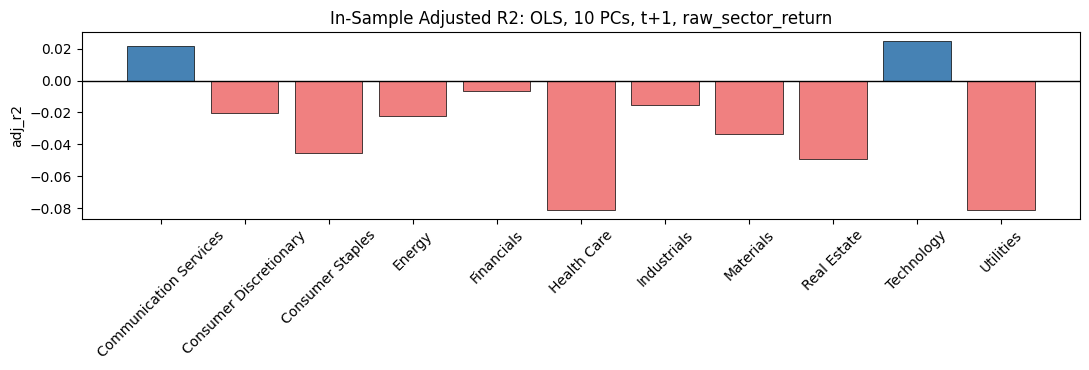

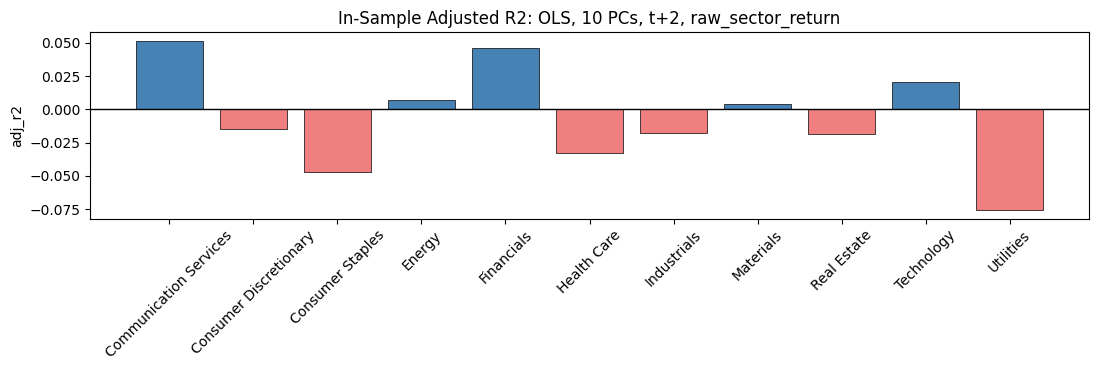

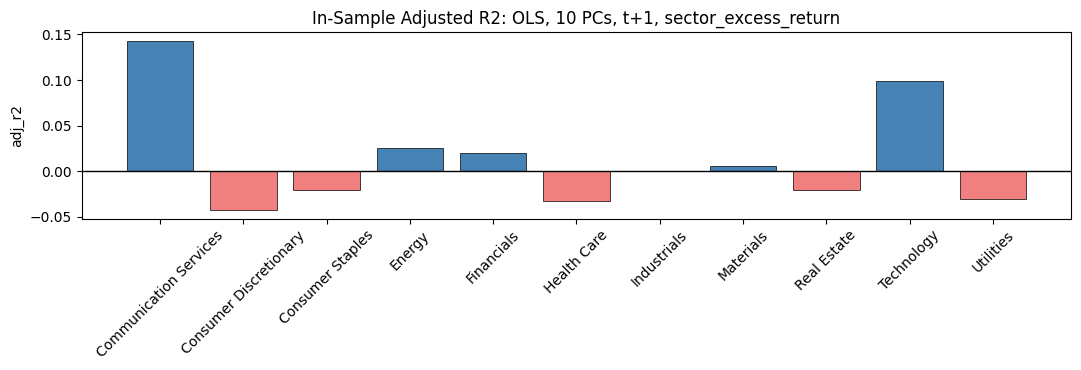

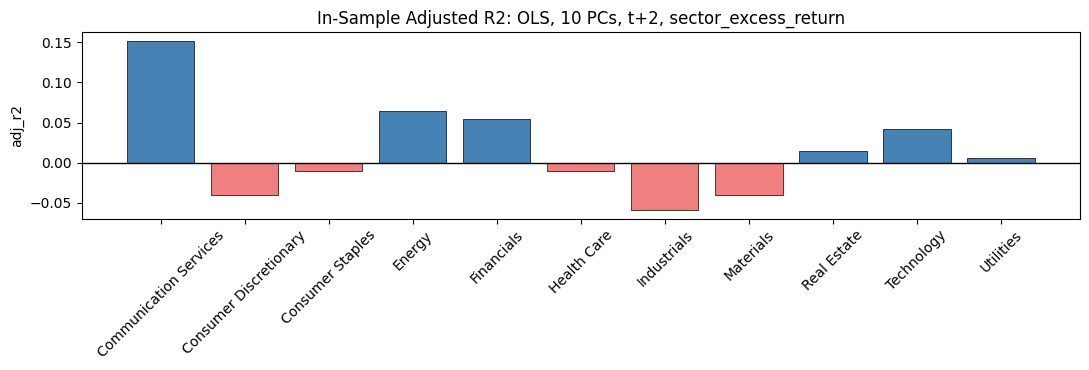

In [30]:
def plot_insample_metric_heatmap(results, target_type, model="OLS", pc_count=10, horizon=1, metric="adj_r2", title=None):
    subset = results[
        (results["target_type"] == target_type)
        & (results["model"] == model)
        & (results["pc_count"] == pc_count)
        & (results["horizon"] == horizon)
    ].copy()
    values = subset.set_index("target")[metric].sort_index()
    display_index = [idx.replace("_excess", "") for idx in values.index]

    fig, ax = plt.subplots(figsize=(11, 3.8))
    colors = np.where(values.values > 0, "steelblue", "lightcoral")
    ax.bar(display_index, values.values, color=colors, edgecolor="black", linewidth=0.5)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(title or f"{metric}: {model}, {pc_count} PCs, t+{horizon}, {target_type}")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

for target_type in ["raw_sector_return", "sector_excess_return"]:
    for horizon in INSAMPLE_HORIZONS:
        plot_insample_metric_heatmap(
            insample_results,
            target_type=target_type,
            model="OLS",
            pc_count=10,
            horizon=horizon,
            metric="adj_r2",
            title=f"In-Sample Adjusted R2: OLS, 10 PCs, t+{horizon}, {target_type}",
        )


In [31]:
# Compare models and PC counts using average adjusted R2 across sectors.
avg_insample = (
    insample_results
    .groupby(["target_type", "horizon", "pc_count", "model"], as_index=False)
    .agg(mean_adj_r2=("adj_r2", "mean"), median_adj_r2=("adj_r2", "median"), max_adj_r2=("adj_r2", "max"))
)

print("Average in-sample adjusted R2 by model/specification:")
avg_insample.sort_values(["target_type", "horizon", "mean_adj_r2"], ascending=[True, True, False]).head(40)


Average in-sample adjusted R2 by model/specification:


,target_type,horizon,pc_count,model,mean_adj_r2,median_adj_r2,max_adj_r2
2,raw_sector_return,1,5,OLS,-0.019599,-0.007083,0.004104
3,raw_sector_return,1,5,Ridge,-0.019611,-0.007100,0.004071
6,raw_sector_return,1,10,OLS,-0.027972,-0.022493,0.024875
7,raw_sector_return,1,10,Ridge,-0.028035,-0.022506,0.024792
10,raw_sector_return,1,13,OLS,-0.030615,-0.026826,0.061653
11,raw_sector_return,1,13,Ridge,-0.030790,-0.026888,0.061477
0,raw_sector_return,1,5,ElasticNet,-0.038037,-0.037143,-0.013793
1,raw_sector_return,1,5,Lasso,-0.052643,-0.056180,-0.038895
4,raw_sector_return,1,10,ElasticNet,-0.077046,-0.061821,-0.043188
8,raw_sector_return,1,13,ElasticNet,-0.106203,-0.100420,-0.043636


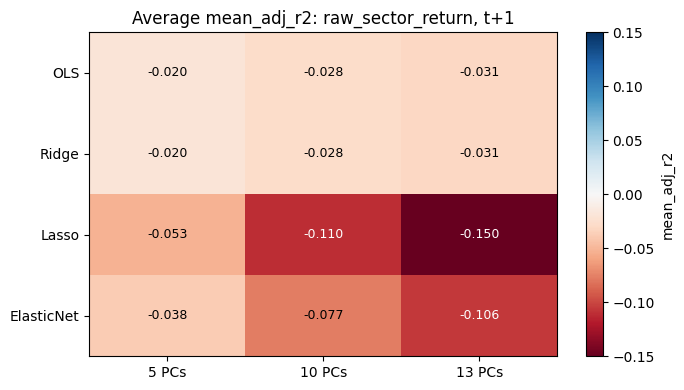

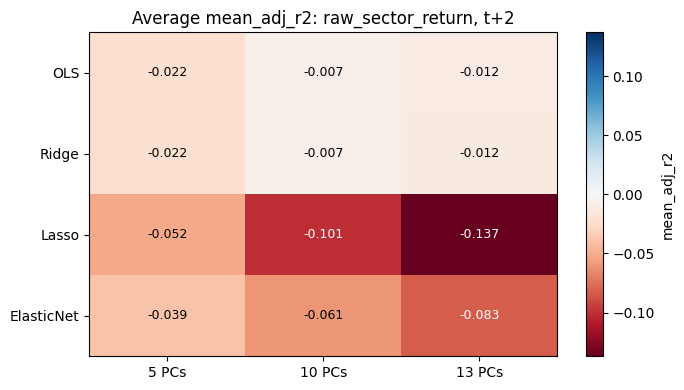

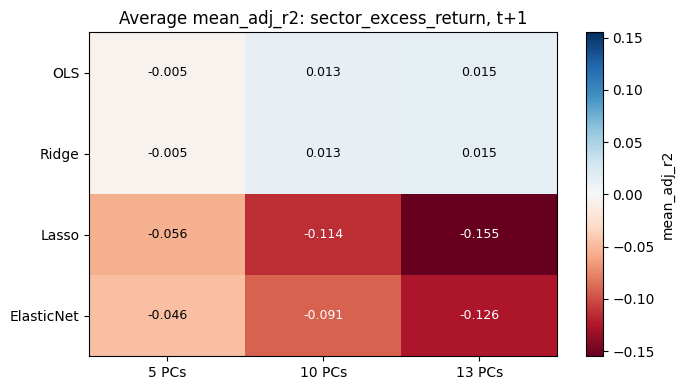

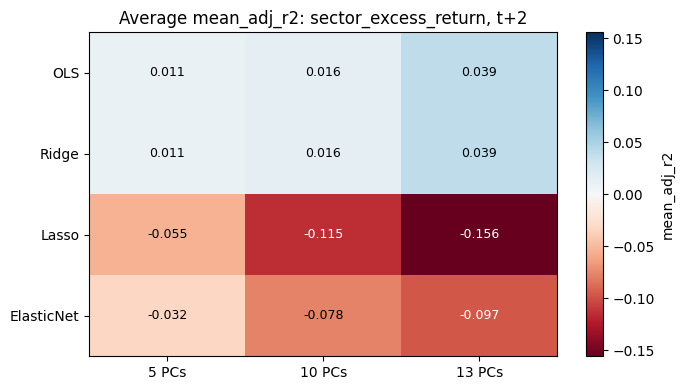

In [32]:
def plot_model_pc_comparison(avg_df, target_type, horizon, metric="mean_adj_r2"):
    subset = avg_df[(avg_df["target_type"] == target_type) & (avg_df["horizon"] == horizon)].copy()
    heat = subset.pivot(index="model", columns="pc_count", values=metric).reindex(INSAMPLE_MODELS)

    fig, ax = plt.subplots(figsize=(7, 4))
    vmax = max(abs(np.nanmin(heat.values)), abs(np.nanmax(heat.values)))
    im = ax.imshow(heat.values.astype(float), cmap="RdBu", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels([f"{c} PCs" for c in heat.columns])
    ax.set_yticks(range(len(heat.index)))
    ax.set_yticklabels(heat.index)
    ax.set_title(f"Average {metric}: {target_type}, t+{horizon}")

    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            val = heat.iloc[i, j]
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=9,
                    color="white" if abs(val) > vmax * 0.55 else "black")

    plt.colorbar(im, ax=ax, label=metric)
    plt.tight_layout()
    plt.show()

for target_type in ["raw_sector_return", "sector_excess_return"]:
    for horizon in INSAMPLE_HORIZONS:
        plot_model_pc_comparison(avg_insample, target_type, horizon)


In [33]:
# Coefficient inspection for strongest OLS 10-PC t+1 relationships.
strong_specs = (
    insample_results[
        (insample_results["model"] == "OLS")
        & (insample_results["pc_count"] == 10)
        & (insample_results["horizon"] == 1)
    ]
    .sort_values("adj_r2", ascending=False)
    .head(8)
)

print("Strongest OLS 10-PC t+1 specs by adjusted R2:")
display(strong_specs[["target_type", "target", "nobs", "r2", "adj_r2"]])

for _, row in strong_specs.iterrows():
    coefs = insample_coefs[
        (insample_coefs["target_type"] == row["target_type"])
        & (insample_coefs["target"] == row["target"])
        & (insample_coefs["model"] == "OLS")
        & (insample_coefs["pc_count"] == 10)
        & (insample_coefs["horizon"] == 1)
    ].copy()
    coefs["abs_coef"] = coefs["coef"].abs()
    print()
    print(f"Top PC coefficients: {row['target_type']} / {row['target']}")
    display(coefs.sort_values("abs_coef", ascending=False).head(5)[["pc", "coef"]])


Strongest OLS 10-PC t+1 specs by adjusted R2:


,target_type,target,nobs,r2,adj_r2
312,sector_excess_return,Communication Services_excess,95,0.234184,0.143016
328,sector_excess_return,Technology_excess,95,0.195140,0.099323
316,sector_excess_return,Energy_excess,95,0.128761,0.025042
64,raw_sector_return,Technology,95,0.128612,0.024875
48,raw_sector_return,Communication Services,95,0.125917,0.021860
320,sector_excess_return,Financials_excess,95,0.124372,0.020130
308,sector_excess_return,Materials_excess,95,0.111254,0.005451
324,sector_excess_return,Industrials_excess,95,0.106390,0.000008



Top PC coefficients: sector_excess_return / Communication Services_excess


,pc,coef
2727,PC4,0.009093
2724,PC1,-0.008815
2725,PC2,-0.008142
2726,PC3,-0.007082
2733,PC10,-0.006020



Top PC coefficients: sector_excess_return / Technology_excess


...

,pc,coef
2812,PC9,0.007346
2808,PC5,-0.005113
2804,PC1,0.004691
2805,PC2,0.004369
2809,PC6,0.003778



Top PC coefficients: sector_excess_return / Materials_excess


,pc,coef
2684,PC1,-0.011895
2692,PC9,-0.007684
2685,PC2,-0.006660
2688,PC5,-0.006552
2693,PC10,0.005719



Top PC coefficients: sector_excess_return / Industrials_excess


,pc,coef
2853,PC10,0.005924
2849,PC6,0.005129
2844,PC1,-0.004719
2846,PC3,-0.002443
2845,PC2,-0.001781


In [34]:
# Save in-sample results.
insample_results.to_csv(RESULTS_DATA_DIR / "insample_model_results.csv", index=False)
insample_coefs.to_csv(RESULTS_DATA_DIR / "insample_model_coefficients.csv", index=False)
avg_insample.to_csv(RESULTS_DATA_DIR / "insample_model_average_results.csv", index=False)

print("Saved in-sample model files:")
print("  insample_model_results.csv")
print("  insample_model_coefficients.csv")
print("  insample_model_average_results.csv")


Saved in-sample model files:
  insample_model_results.csv
  insample_model_coefficients.csv
  insample_model_average_results.csv


## 5. Out-of-Sample Forecasting

This section evaluates whether the attention factors forecast sector returns out of sample. PCA is re-estimated in an expanding window at each forecast date, so no future Google Trends data enters the PC scores. Return models are also fit only on past observations. The benchmark forecast is the historical mean return using the same training window.


In [35]:
# OOS helpers: PCA without look-ahead and model fitting/prediction.
try:
    from sklearn.decomposition import PCA as SklearnPCA
    from sklearn.preprocessing import StandardScaler as SklearnStandardScaler
    from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
    from sklearn.model_selection import TimeSeriesSplit
    SKLEARN_OOS_AVAILABLE = True
    print("Using scikit-learn for OOS PCA/model tuning")
except ModuleNotFoundError:
    SKLEARN_OOS_AVAILABLE = False
    print("scikit-learn not found in this kernel; using NumPy OOS fallback")


def fit_pca_scores_expanding(trends_by_date, end_date, n_components):
    train_panel = trends_by_date.loc[:end_date].copy()
    mu = train_panel.mean(axis=0)
    sig = train_panel.std(axis=0, ddof=0)
    keep_cols = sig[sig > 0].index
    train_panel = train_panel[keep_cols]
    mu = mu[keep_cols]
    sig = sig[keep_cols]

    X_train = ((train_panel - mu) / sig).to_numpy(dtype=float)
    n_keep = min(n_components, X_train.shape[0], X_train.shape[1])

    if SKLEARN_OOS_AVAILABLE:
        pca_local = SklearnPCA(n_components=n_keep)
        scores = pca_local.fit_transform(X_train)
    else:
        X_centered = X_train - X_train.mean(axis=0)
        _, _, vt = np.linalg.svd(X_centered, full_matrices=False)
        components = vt[:n_keep]
        scores = X_centered @ components.T

    return pd.DataFrame(
        scores,
        index=train_panel.index,
        columns=[f"PC{i}" for i in range(1, n_keep + 1)],
    )


def fit_predict_oos_model(X_train, y_train, X_test, model_name):
    X_train = np.asarray(X_train, dtype=float)
    y_train = np.asarray(y_train, dtype=float)
    X_test = np.asarray(X_test, dtype=float).reshape(1, -1)

    mu = X_train.mean(axis=0)
    sig = X_train.std(axis=0, ddof=0)
    sig[sig == 0] = 1.0
    X_train_s = (X_train - mu) / sig
    X_test_s = (X_test - mu) / sig

    if model_name == "OLS":
        _, intercept, coef = fit_ols_np(X_train_s, y_train)
        return float((intercept + X_test_s @ coef).ravel()[0]), {"alpha": np.nan, "l1_ratio": np.nan}

    if SKLEARN_OOS_AVAILABLE:
        n_splits = min(5, max(2, len(y_train) // 18))
        cv = TimeSeriesSplit(n_splits=n_splits)
        if model_name == "Ridge":
            model = RidgeCV(alphas=np.logspace(-3, 3, 13), cv=cv)
        elif model_name == "Lasso":
            model = LassoCV(alphas=np.logspace(-4, 0, 13), cv=cv, max_iter=10000, random_state=42)
        elif model_name == "ElasticNet":
            model = ElasticNetCV(
                alphas=np.logspace(-4, 0, 13),
                l1_ratio=[0.2, 0.5, 0.8],
                cv=cv,
                max_iter=10000,
                random_state=42,
            )
        else:
            raise ValueError(model_name)
        model.fit(X_train_s, y_train)
        pred = float(model.predict(X_test_s)[0])
        return pred, {"alpha": getattr(model, "alpha_", np.nan), "l1_ratio": getattr(model, "l1_ratio_", np.nan)}

    # Fast fallback if sklearn is unavailable in nbconvert.
    if model_name == "Ridge":
        alpha = 1.0
        _, intercept, coef = fit_ridge_np(X_train_s, y_train, alpha)
        return float((intercept + X_test_s @ coef).ravel()[0]), {"alpha": alpha, "l1_ratio": np.nan}
    if model_name == "Lasso":
        alpha = 0.01
        _, intercept, coef = fit_elastic_net_cd(X_train_s, y_train, alpha, l1_ratio=1.0, max_iter=1000)
        return float((intercept + X_test_s @ coef).ravel()[0]), {"alpha": alpha, "l1_ratio": 1.0}
    if model_name == "ElasticNet":
        alpha = 0.01
        l1_ratio = 0.5
        _, intercept, coef = fit_elastic_net_cd(X_train_s, y_train, alpha, l1_ratio=l1_ratio, max_iter=1000)
        return float((intercept + X_test_s @ coef).ravel()[0]), {"alpha": alpha, "l1_ratio": l1_ratio}
    raise ValueError(model_name)


scikit-learn not found in this kernel; using NumPy OOS fallback


In [36]:
# Build OOS forecast loop.
OOS_MODELS = ["OLS", "Ridge", "Lasso", "ElasticNet"]
OOS_PC_COUNTS = [5, 10, 13]
OOS_HORIZONS = [1, 2]
MIN_TRAIN_OBS = 60
OOS_PCA_CACHE = {}

# trends_by_date has dates as rows and keywords as columns.
trends_by_date = trends_keywords.T.sort_index()
trends_by_date.index.name = "date"


def run_oos_for_target(target_series, target_type, target_name, pc_count, horizon, model_name, min_train=MIN_TRAIN_OBS):
    target_series = target_series.dropna().sort_index()
    feature_dates = trends_by_date.index.intersection(target_series.index)
    y_future = target_series.shift(-horizon)

    preds = []
    actuals = []
    benchmarks = []
    dates = []
    alphas = []
    l1_ratios = []

    # Need enough data before the forecast date and an available future target.
    for pos in range(min_train, len(feature_dates) - horizon):
        forecast_date = feature_dates[pos]
        if pd.isna(y_future.loc[forecast_date]):
            continue

        cache_key = (pc_count, forecast_date)
        if cache_key not in OOS_PCA_CACHE:
            OOS_PCA_CACHE[cache_key] = fit_pca_scores_expanding(trends_by_date, forecast_date, pc_count)
        pca_scores_expanding = OOS_PCA_CACHE[cache_key]
        pc_cols = [f"PC{i}" for i in range(1, min(pc_count, pca_scores_expanding.shape[1]) + 1)]

        train_dates = [d for d in feature_dates[:pos] if d in pca_scores_expanding.index and not pd.isna(y_future.loc[d])]
        if len(train_dates) < min_train:
            continue

        X_train = pca_scores_expanding.loc[train_dates, pc_cols]
        y_train = y_future.loc[train_dates]
        X_test = pca_scores_expanding.loc[forecast_date, pc_cols]
        y_test = y_future.loc[forecast_date]

        pred, params = fit_predict_oos_model(X_train, y_train, X_test, model_name)
        benchmark = float(y_train.mean())

        preds.append(pred)
        actuals.append(float(y_test))
        benchmarks.append(benchmark)
        dates.append(forecast_date)
        alphas.append(params.get("alpha", np.nan))
        l1_ratios.append(params.get("l1_ratio", np.nan))

    if not preds:
        return None, None

    pred_df = pd.DataFrame({
        "date": dates,
        "target_type": target_type,
        "target": target_name,
        "pc_count": pc_count,
        "horizon": horizon,
        "model": model_name,
        "actual": actuals,
        "prediction": preds,
        "benchmark": benchmarks,
        "alpha": alphas,
        "l1_ratio": l1_ratios,
    }).set_index("date")

    actual = pred_df["actual"].to_numpy()
    pred = pred_df["prediction"].to_numpy()
    bench = pred_df["benchmark"].to_numpy()
    msfe_model = float(np.mean((actual - pred) ** 2))
    msfe_bench = float(np.mean((actual - bench) ** 2))
    oos_r2 = np.nan if msfe_bench == 0 else 1 - msfe_model / msfe_bench
    directional_accuracy = float(np.mean(np.sign(pred) == np.sign(actual)))

    summary = {
        "target_type": target_type,
        "target": target_name,
        "pc_count": pc_count,
        "horizon": horizon,
        "model": model_name,
        "n_oos": len(pred_df),
        "start": pred_df.index.min(),
        "end": pred_df.index.max(),
        "oos_r2": oos_r2,
        "msfe_model": msfe_model,
        "msfe_benchmark": msfe_bench,
        "msfe_ratio": np.nan if msfe_bench == 0 else msfe_model / msfe_bench,
        "directional_accuracy": directional_accuracy,
    }
    return summary, pred_df.reset_index()


In [37]:
# Run OOS suite. This may take a bit because PCA is re-estimated at each forecast date.
oos_summaries = []
oos_predictions_list = []

target_blocks = [
    ("raw_sector_return", sector_returns_aligned),
    ("sector_excess_return", sector_excess_aligned),
]

for target_type, target_df in target_blocks:
    for target in target_df.columns:
        for horizon in OOS_HORIZONS:
            for pc_count in OOS_PC_COUNTS:
                for model_name in OOS_MODELS:
                    summary, pred_df = run_oos_for_target(
                        target_df[target],
                        target_type=target_type,
                        target_name=target,
                        pc_count=pc_count,
                        horizon=horizon,
                        model_name=model_name,
                    )
                    if summary is not None:
                        oos_summaries.append(summary)
                        oos_predictions_list.append(pred_df)

oos_results = pd.DataFrame(oos_summaries)
oos_predictions = pd.concat(oos_predictions_list, ignore_index=True) if oos_predictions_list else pd.DataFrame()

print(f"OOS result rows: {len(oos_results):,}")
print(f"OOS prediction rows: {len(oos_predictions):,}")
print("Best OOS R2 rows:")
oos_results.sort_values("oos_r2", ascending=False).head(25)


OOS result rows: 528
OOS prediction rows: 29,688
Best OOS R2 rows:


,target_type,target,pc_count,horizon,model,n_oos,start,end,oos_r2,msfe_model,msfe_benchmark,msfe_ratio,directional_accuracy
307,sector_excess_return,Communication Services_excess,10,2,ElasticNet,33,2023-07-01,2026-03-01,0.058690,0.000455,0.000483,0.941310,0.424242
303,sector_excess_return,Communication Services_excess,5,2,ElasticNet,33,2023-07-01,2026-03-01,0.058642,0.000455,0.000483,0.941358,0.484848
289,sector_excess_return,Communication Services_excess,5,1,Ridge,34,2023-07-01,2026-04-01,0.058305,0.000443,0.000470,0.941695,0.529412
311,sector_excess_return,Communication Services_excess,13,2,ElasticNet,33,2023-07-01,2026-03-01,0.057091,0.000455,0.000483,0.942909,0.484848
288,sector_excess_return,Communication Services_excess,5,1,OLS,34,2023-07-01,2026-04-01,0.056839,0.000443,0.000470,0.943161,0.529412
479,sector_excess_return,Utilities_excess,13,2,ElasticNet,58,2021-06-01,2026-03-01,0.041781,0.001821,0.001901,0.958219,0.568966
46,raw_sector_return,Communication Services,13,2,Lasso,33,2023-07-01,2026-03-01,0.030653,0.001481,0.001527,0.969347,0.636364
301,sector_excess_return,Communication Services_excess,5,2,Ridge,33,2023-07-01,2026-03-01,0.023347,0.000472,0.000483,0.976653,0.515152
300,sector_excess_return,Communication Services_excess,5,2,OLS,33,2023-07-01,2026-03-01,0.020683,0.000473,0.000483,0.979317,0.515152
42,raw_sector_return,Communication Services,10,2,Lasso,33,2023-07-01,2026-03-01,0.017364,0.001501,0.001527,0.982636,0.636364


In [38]:
# OOS summary by model/specification.
oos_avg = (
    oos_results
    .groupby(["target_type", "horizon", "pc_count", "model"], as_index=False)
    .agg(
        mean_oos_r2=("oos_r2", "mean"),
        median_oos_r2=("oos_r2", "median"),
        max_oos_r2=("oos_r2", "max"),
        mean_directional_accuracy=("directional_accuracy", "mean"),
    )
)

print("Average OOS results by model/specification:")
oos_avg.sort_values(["target_type", "horizon", "mean_oos_r2"], ascending=[True, True, False]).head(60)


Average OOS results by model/specification:


,target_type,horizon,pc_count,model,mean_oos_r2,median_oos_r2,max_oos_r2,mean_directional_accuracy
1,raw_sector_return,1,5,Lasso,-0.005950,-0.001798,0.000000,0.566165
5,raw_sector_return,1,10,Lasso,-0.007719,-0.005632,0.000000,0.570380
9,raw_sector_return,1,13,Lasso,-0.019282,-0.013393,0.000017,0.559277
0,raw_sector_return,1,5,ElasticNet,-0.037577,-0.027836,-0.000042,0.542645
4,raw_sector_return,1,10,ElasticNet,-0.062310,-0.071437,0.000521,0.547358
8,raw_sector_return,1,13,ElasticNet,-0.109217,-0.095092,0.001682,0.538929
3,raw_sector_return,1,5,Ridge,-0.158355,-0.153694,-0.102346,0.508746
2,raw_sector_return,1,5,OLS,-0.161610,-0.157241,-0.104852,0.508746
7,raw_sector_return,1,10,Ridge,-0.313681,-0.297435,-0.192974,0.514185
6,raw_sector_return,1,10,OLS,-0.325591,-0.304144,-0.201965,0.515726


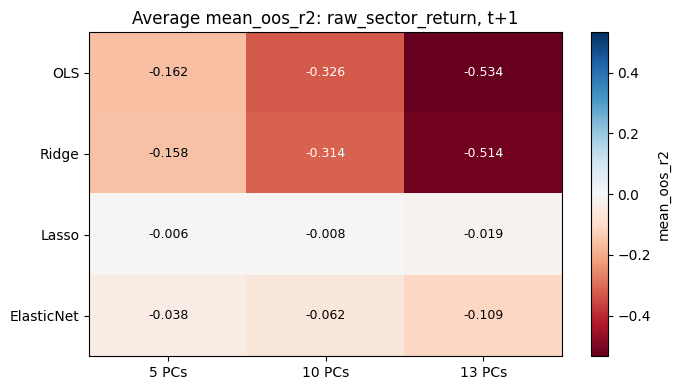

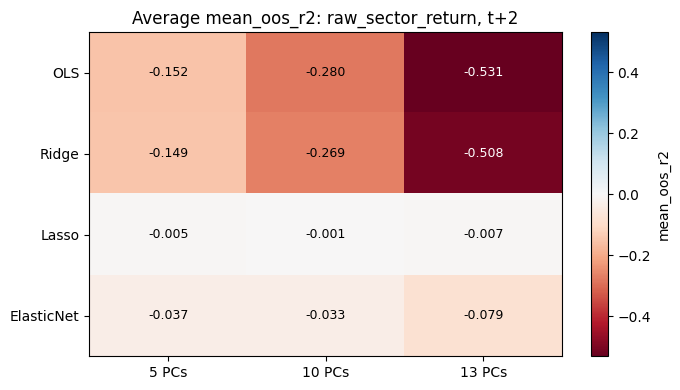

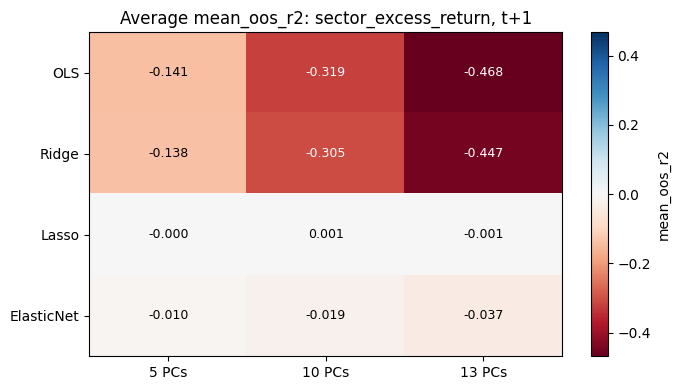

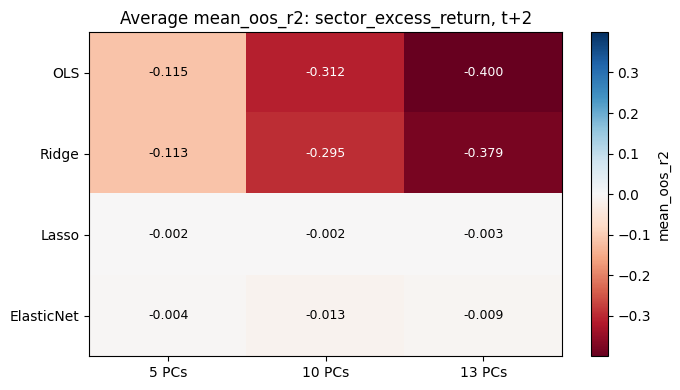

In [39]:
def plot_oos_model_pc_heatmap(avg_df, target_type, horizon, metric="mean_oos_r2"):
    subset = avg_df[(avg_df["target_type"] == target_type) & (avg_df["horizon"] == horizon)].copy()
    heat = subset.pivot(index="model", columns="pc_count", values=metric).reindex(OOS_MODELS)

    fig, ax = plt.subplots(figsize=(7, 4))
    vmax = max(abs(np.nanmin(heat.values)), abs(np.nanmax(heat.values)), 0.01)
    im = ax.imshow(heat.values.astype(float), cmap="RdBu", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels([f"{c} PCs" for c in heat.columns])
    ax.set_yticks(range(len(heat.index)))
    ax.set_yticklabels(heat.index)
    ax.set_title(f"Average {metric}: {target_type}, t+{horizon}")

    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            val = heat.iloc[i, j]
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=9,
                    color="white" if abs(val) > vmax * 0.55 else "black")

    plt.colorbar(im, ax=ax, label=metric)
    plt.tight_layout()
    plt.show()

for target_type in ["raw_sector_return", "sector_excess_return"]:
    for horizon in OOS_HORIZONS:
        plot_oos_model_pc_heatmap(oos_avg, target_type, horizon, metric="mean_oos_r2")


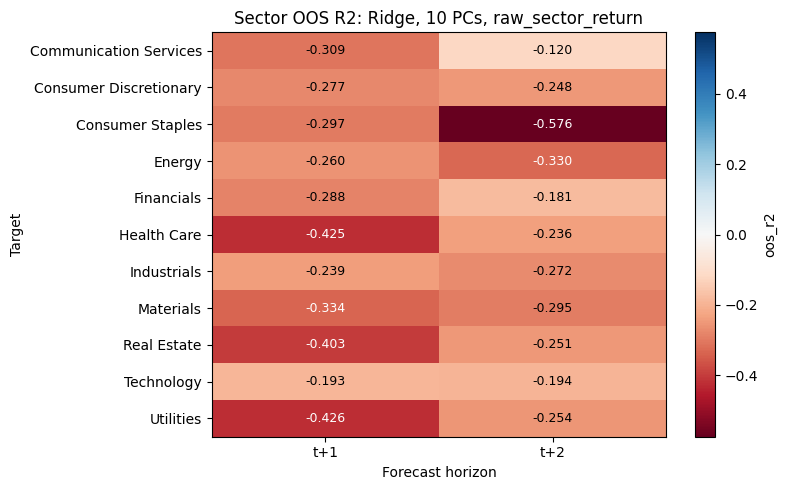

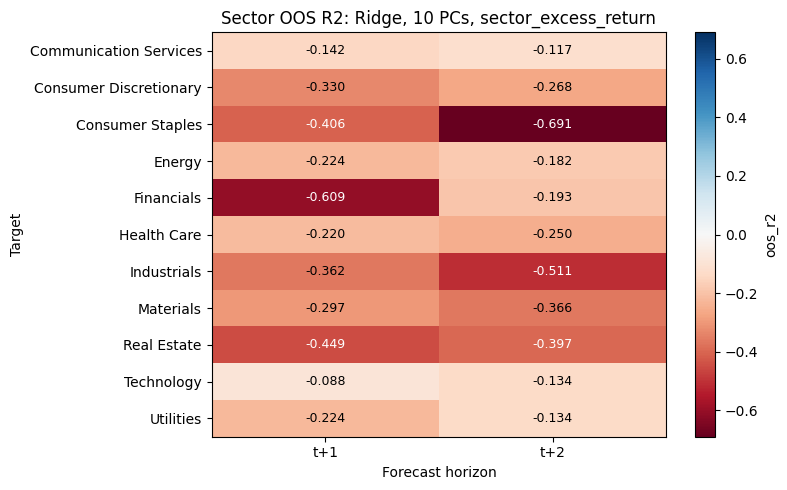

In [40]:
# Sector-level OOS heatmaps for the main 10-PC specification.
def plot_sector_oos_heatmap(results, target_type, model="Ridge", pc_count=10, metric="oos_r2"):
    subset = results[
        (results["target_type"] == target_type)
        & (results["model"] == model)
        & (results["pc_count"] == pc_count)
    ].copy()
    heat = subset.pivot(index="target", columns="horizon", values=metric).sort_index()
    display_index = [idx.replace("_excess", "") for idx in heat.index]

    fig, ax = plt.subplots(figsize=(8, max(5, 0.42 * len(heat))))
    vmax = max(abs(np.nanmin(heat.values)), abs(np.nanmax(heat.values)), 0.01)
    im = ax.imshow(heat.values.astype(float), cmap="RdBu", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels([f"t+{h}" for h in heat.columns])
    ax.set_yticks(range(len(heat.index)))
    ax.set_yticklabels(display_index)
    ax.set_title(f"Sector OOS R2: {model}, {pc_count} PCs, {target_type}")
    ax.set_xlabel("Forecast horizon")
    ax.set_ylabel("Target")

    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            val = heat.iloc[i, j]
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=9,
                    color="white" if abs(val) > vmax * 0.55 else "black")

    plt.colorbar(im, ax=ax, label=metric)
    plt.tight_layout()
    plt.show()

for target_type in ["raw_sector_return", "sector_excess_return"]:
    plot_sector_oos_heatmap(oos_results, target_type, model="Ridge", pc_count=10)


Strongest OOS cases:


,target_type,target,horizon,pc_count,model,n_oos,oos_r2,directional_accuracy
307,sector_excess_return,Communication Services_excess,2,10,ElasticNet,33,0.058690,0.424242
303,sector_excess_return,Communication Services_excess,2,5,ElasticNet,33,0.058642,0.484848
289,sector_excess_return,Communication Services_excess,1,5,Ridge,34,0.058305,0.529412
311,sector_excess_return,Communication Services_excess,2,13,ElasticNet,33,0.057091,0.484848
288,sector_excess_return,Communication Services_excess,1,5,OLS,34,0.056839,0.529412
479,sector_excess_return,Utilities_excess,2,13,ElasticNet,58,0.041781,0.568966


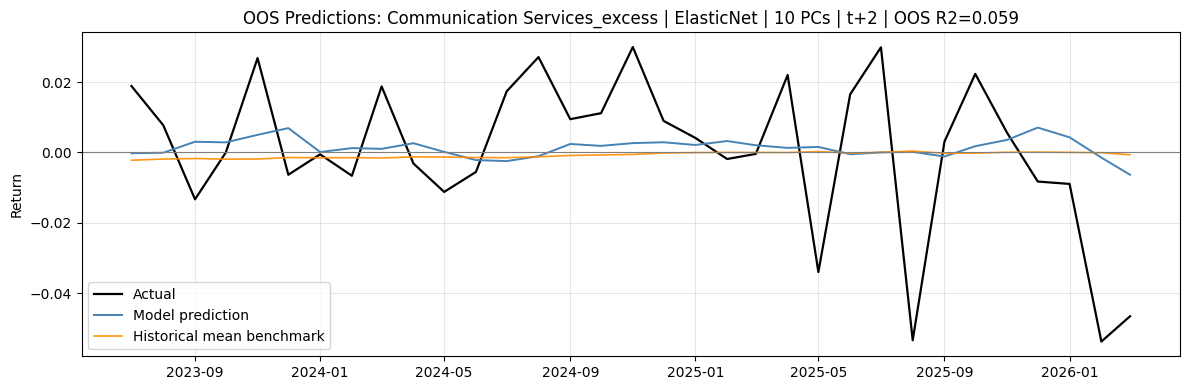

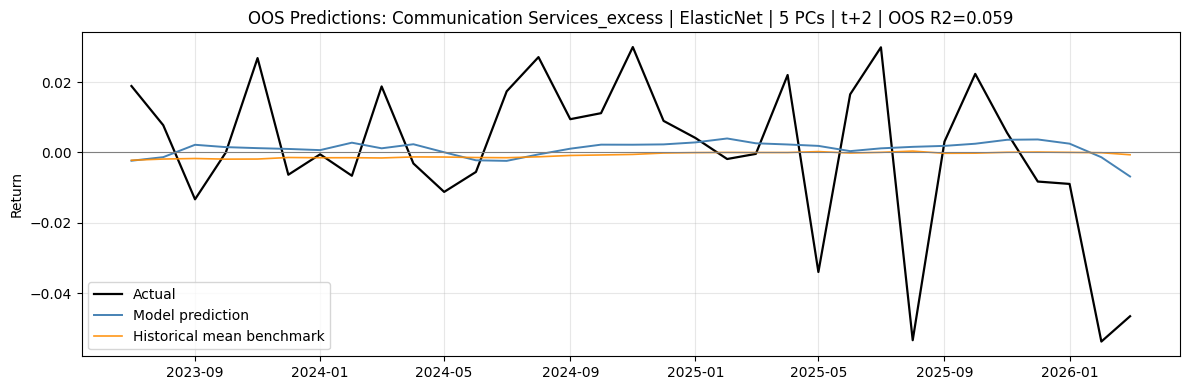

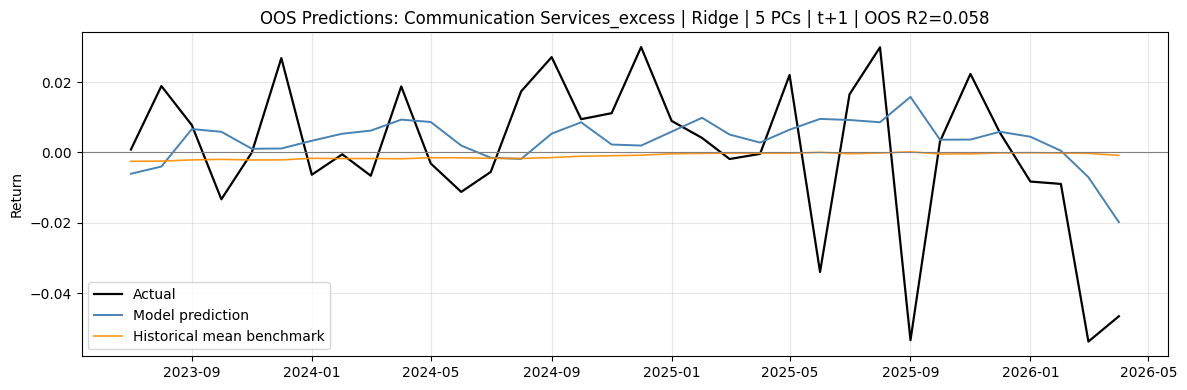

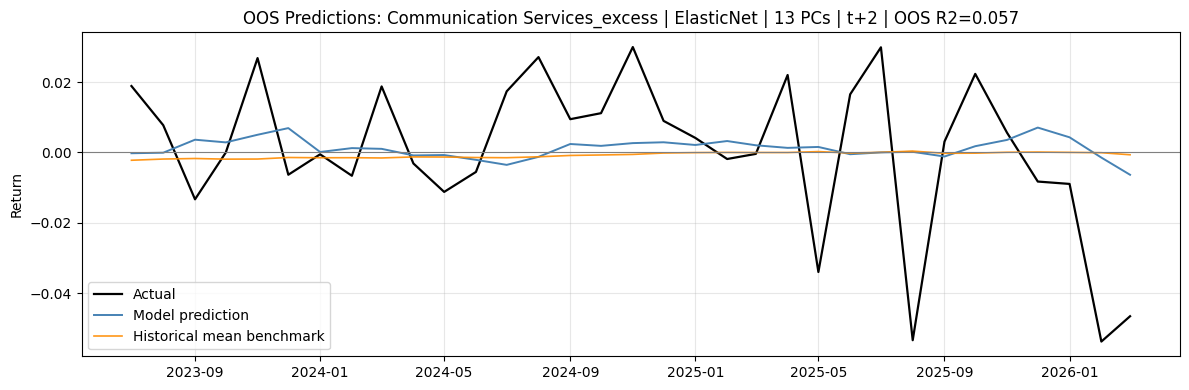

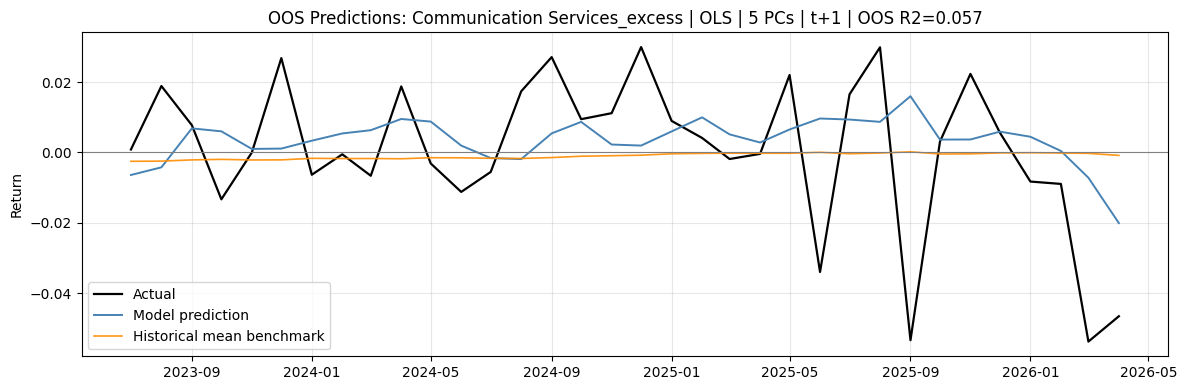

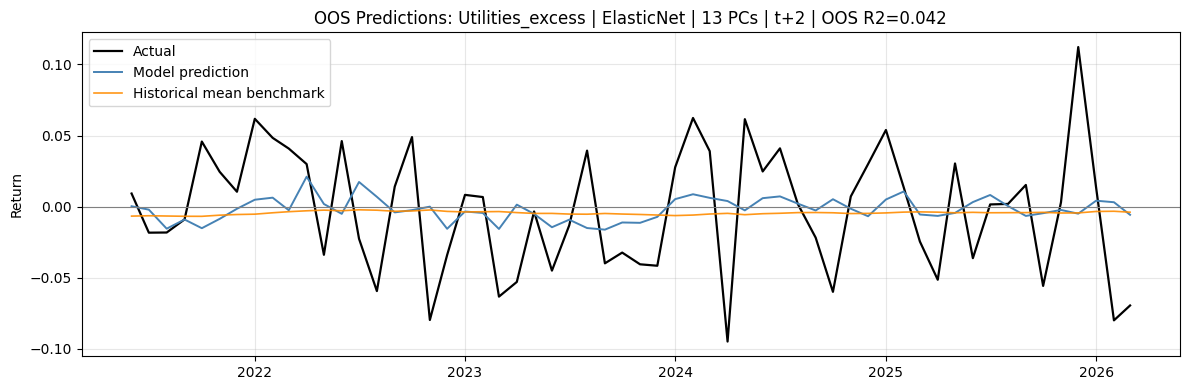

In [41]:
# Plot predictions for strongest positive OOS R2 cases.
strong_oos = oos_results.sort_values("oos_r2", ascending=False).head(6)
print("Strongest OOS cases:")
display(strong_oos[["target_type", "target", "horizon", "pc_count", "model", "n_oos", "oos_r2", "directional_accuracy"]])

for _, row in strong_oos.iterrows():
    pred_case = oos_predictions[
        (oos_predictions["target_type"] == row["target_type"])
        & (oos_predictions["target"] == row["target"])
        & (oos_predictions["horizon"] == row["horizon"])
        & (oos_predictions["pc_count"] == row["pc_count"])
        & (oos_predictions["model"] == row["model"])
    ].copy()
    pred_case["date"] = pd.to_datetime(pred_case["date"])
    pred_case = pred_case.sort_values("date")

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(pred_case["date"], pred_case["actual"], label="Actual", color="black", linewidth=1.6)
    ax.plot(pred_case["date"], pred_case["prediction"], label="Model prediction", color="steelblue", linewidth=1.4)
    ax.plot(pred_case["date"], pred_case["benchmark"], label="Historical mean benchmark", color="darkorange", linewidth=1.2, alpha=0.9)
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_title(f"OOS Predictions: {row['target']} | {row['model']} | {row['pc_count']} PCs | t+{row['horizon']} | OOS R2={row['oos_r2']:.3f}")
    ax.set_ylabel("Return")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


In [42]:
# Save OOS outputs.
oos_results.to_csv(RESULTS_DATA_DIR / "oos_model_results.csv", index=False)
oos_predictions.to_csv(RESULTS_DATA_DIR / "oos_model_predictions.csv", index=False)
oos_avg.to_csv(RESULTS_DATA_DIR / "oos_model_average_results.csv", index=False)

print("Saved OOS model files:")
print("  oos_model_results.csv")
print("  oos_model_predictions.csv")
print("  oos_model_average_results.csv")


Saved OOS model files:
  oos_model_results.csv
  oos_model_predictions.csv
  oos_model_average_results.csv


## 6. Portfolio-style alpha test

Use the OOS forecasts to form a simple sector-rotation portfolio. Each month, rank sectors by predicted next-month sector excess return, hold the top 3 sectors equally, and compare realized performance against SPY and an equal-weight sector portfolio.

In [105]:
# Build portfolio backtests from OOS forecasts.
TOP_N_SECTORS = 3
PORTFOLIO_TARGET_TYPE = "sector_excess_return"
PORTFOLIO_HORIZON = 1
PORTFOLIO_PC_COUNTS = [5, 10, 13]
PORTFOLIO_MODELS = ["OLS", "Ridge", "Lasso", "ElasticNet"]

# The strategy ranks sectors using predicted excess returns, but realized portfolio
# returns are computed from the raw sector ETF returns.
sector_raw_for_port = sector_returns_aligned.copy()
spy_for_port = spy_returns_aligned.iloc[:, 0].copy()
spy_for_port.name = "SPY"


def max_drawdown(return_series):
    cumulative = (1 + return_series.dropna()).cumprod()
    if cumulative.empty:
        return np.nan
    running_peak = cumulative.cummax()
    drawdown = cumulative / running_peak - 1
    return drawdown.min()


def annualized_return(return_series, periods_per_year=12):
    returns = return_series.dropna()
    if returns.empty:
        return np.nan
    cumulative = (1 + returns).prod()
    return cumulative ** (periods_per_year / len(returns)) - 1


def annualized_volatility(return_series, periods_per_year=12):
    returns = return_series.dropna()
    if len(returns) < 2:
        return np.nan
    return returns.std(ddof=1) * np.sqrt(periods_per_year)


def annualized_sharpe(return_series, periods_per_year=12):
    returns = return_series.dropna()
    vol = annualized_volatility(returns, periods_per_year)
    if pd.isna(vol) or vol == 0:
        return np.nan
    return returns.mean() / returns.std(ddof=1) * np.sqrt(periods_per_year)


def average_turnover(holdings_by_date):
    if len(holdings_by_date) < 2:
        return np.nan
    turnovers = []
    previous = None
    for _, holdings in holdings_by_date:
        current = {sector: 1 / len(holdings) for sector in holdings}
        if previous is not None:
            names = set(previous) | set(current)
            turnover = 0.5 * sum(abs(current.get(name, 0) - previous.get(name, 0)) for name in names)
            turnovers.append(turnover)
        previous = current
    return np.mean(turnovers) if turnovers else np.nan


def build_top_n_strategy(predictions, model, pc_count, horizon=PORTFOLIO_HORIZON, top_n=TOP_N_SECTORS):
    subset = predictions[
        (predictions["target_type"] == PORTFOLIO_TARGET_TYPE)
        & (predictions["model"] == model)
        & (predictions["pc_count"] == pc_count)
        & (predictions["horizon"] == horizon)
    ].copy()
    subset["date"] = pd.to_datetime(subset["date"])

    rows = []
    holdings_by_date = []
    for date, date_preds in subset.groupby("date"):
        ranked = date_preds.dropna(subset=["prediction"]).sort_values("prediction", ascending=False)
        selected = ranked.head(top_n)["target"].str.replace("_excess", "", regex=False).tolist()
        selected = [sector for sector in selected if sector in sector_raw_for_port.columns]
        if len(selected) == 0 or date not in sector_raw_for_port.index or date not in spy_for_port.index:
            continue

        raw_returns = sector_raw_for_port.loc[date, selected].dropna()
        if raw_returns.empty:
            continue

        available_selected = raw_returns.index.tolist()
        holdings_by_date.append((date, available_selected))
        strategy_return = raw_returns.mean()
        spy_return = spy_for_port.loc[date]
        equal_weight_return = sector_raw_for_port.loc[date].dropna().mean()

        rows.append({
            "date": date,
            "model": model,
            "pc_count": pc_count,
            "horizon": horizon,
            "n_holdings": len(available_selected),
            "holdings": ", ".join(available_selected),
            "strategy_return": strategy_return,
            "spy_return": spy_return,
            "equal_weight_sector_return": equal_weight_return,
            "strategy_excess_vs_spy": strategy_return - spy_return,
            "strategy_excess_vs_equal_weight": strategy_return - equal_weight_return,
        })

    strategy = pd.DataFrame(rows).sort_values("date")
    turnover = average_turnover(holdings_by_date)
    return strategy, turnover


strategy_frames = []
strategy_summary_rows = []

for model in PORTFOLIO_MODELS:
    for pc_count in PORTFOLIO_PC_COUNTS:
        strategy, turnover = build_top_n_strategy(oos_predictions, model=model, pc_count=pc_count)
        if strategy.empty:
            continue
        strategy_frames.append(strategy)
        strategy_summary_rows.append({
            "model": model,
            "pc_count": pc_count,
            "horizon": PORTFOLIO_HORIZON,
            "n_months": len(strategy),
            "start": strategy["date"].min(),
            "end": strategy["date"].max(),
            "ann_return": annualized_return(strategy["strategy_return"]),
            "ann_volatility": annualized_volatility(strategy["strategy_return"]),
            "sharpe": annualized_sharpe(strategy["strategy_return"]),
            "ann_excess_return_vs_spy": strategy["strategy_excess_vs_spy"].mean() * 12,
            "excess_sharpe_vs_spy": annualized_sharpe(strategy["strategy_excess_vs_spy"]),
            "max_drawdown": max_drawdown(strategy["strategy_return"]),
            "avg_monthly_turnover": turnover,
            "spy_ann_return": annualized_return(strategy["spy_return"]),
            "spy_sharpe": annualized_sharpe(strategy["spy_return"]),
            "equal_weight_ann_return": annualized_return(strategy["equal_weight_sector_return"]),
            "equal_weight_sharpe": annualized_sharpe(strategy["equal_weight_sector_return"]),
        })

portfolio_backtests = pd.concat(strategy_frames, ignore_index=True) if strategy_frames else pd.DataFrame()
portfolio_summary = pd.DataFrame(strategy_summary_rows)

print(f"Built top-{TOP_N_SECTORS} sector-rotation strategies using {PORTFOLIO_TARGET_TYPE}, t+{PORTFOLIO_HORIZON} forecasts.")
print(f"Strategy rows: {len(portfolio_backtests):,}")

display(
    portfolio_summary
    .sort_values("sharpe", ascending=False)
    [["model", "pc_count", "n_months", "ann_return", "ann_volatility", "sharpe", "ann_excess_return_vs_spy", "excess_sharpe_vs_spy", "max_drawdown", "avg_monthly_turnover", "spy_sharpe", "equal_weight_sharpe"]]
    .round(4)
)


Built top-3 sector-rotation strategies using sector_excess_return, t+1 forecasts.
Strategy rows: 708


,model,pc_count,n_months,ann_return,ann_volatility,sharpe,ann_excess_return_vs_spy,excess_sharpe_vs_spy,max_drawdown,avg_monthly_turnover,spy_sharpe,equal_weight_sharpe
1,OLS,10,59,0.3413,0.1583,1.9544,0.1729,1.9111,-0.1222,0.3391,0.8464,0.7717
2,OLS,13,59,0.3144,0.1655,1.7507,0.1532,1.6825,-0.1222,0.4425,0.8464,0.7717
0,OLS,5,59,0.2886,0.1547,1.7303,0.1312,1.2012,-0.0971,0.3448,0.8464,0.7717
5,Ridge,13,59,0.2874,0.1805,1.5008,0.1344,2.0458,-0.1776,0.4023,0.8464,0.7717
4,Ridge,10,59,0.2639,0.1702,1.4715,0.1139,1.9563,-0.1823,0.2931,0.8464,0.7717
3,Ridge,5,59,0.2030,0.1400,1.3979,0.0592,0.8179,-0.1563,0.1494,0.8464,0.7717
10,ElasticNet,10,59,0.2409,0.1813,1.2884,0.0971,1.5720,-0.2095,0.3046,0.8464,0.7717
6,Lasso,5,59,0.2265,0.1780,1.2420,0.0846,1.5040,-0.1607,0.2069,0.8464,0.7717
11,ElasticNet,13,59,0.2265,0.1809,1.2261,0.0852,1.3645,-0.2563,0.3793,0.8464,0.7717
9,ElasticNet,5,59,0.2150,0.1739,1.2123,0.0743,1.2587,-0.2079,0.2126,0.8464,0.7717


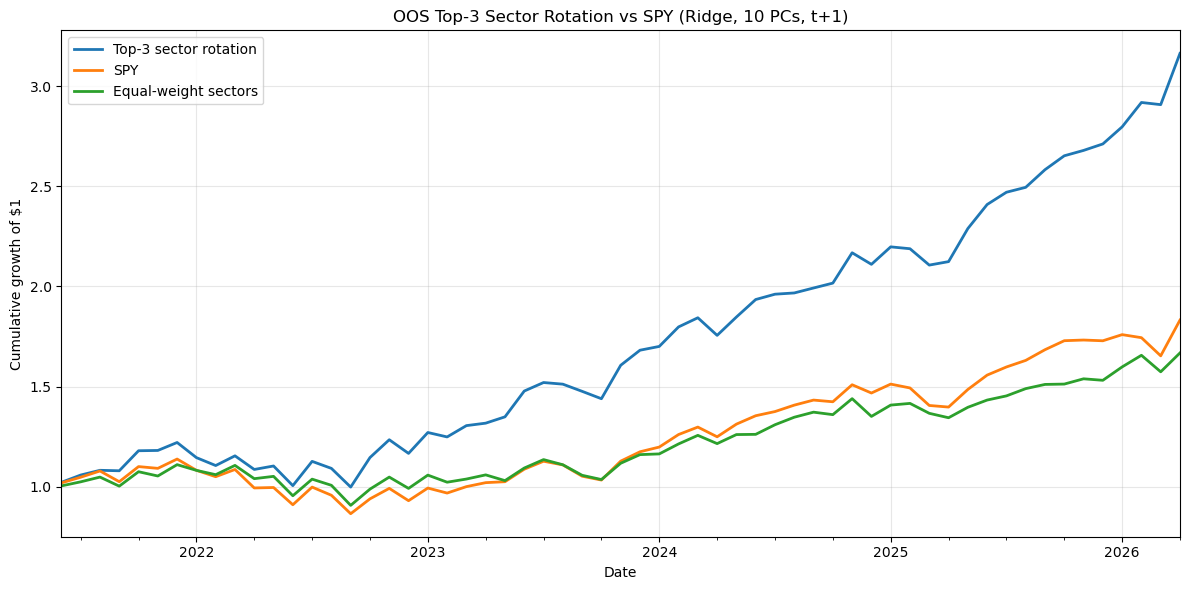

Recent main-strategy holdings:


,date,holdings,strategy_return,spy_return,strategy_excess_vs_spy
47,2025-05-01,"Technology, Financials, Industrials",0.077750,0.062845,0.014905
48,2025-06-01,"Financials, Technology, Industrials",0.052413,0.048287,0.004126
49,2025-07-01,"Financials, Technology, Industrials",0.025425,0.026056,-0.000631
50,2025-08-01,"Financials, Technology, Industrials",0.009943,0.020520,-0.010576
51,2025-09-01,"Financials, Technology, Consumer Discretionary",0.035275,0.032757,0.002518
52,2025-10-01,"Technology, Consumer Discretionary, Industrials",0.026884,0.026676,0.000208
53,2025-11-01,"Technology, Consumer Discretionary, Health Care",0.010114,0.001950,0.008164
54,2025-12-01,"Communication Services, Technology, Consumer D...",0.012061,-0.002151,0.014212
55,2026-01-01,"Technology, Communication Services, Industrials",0.031474,0.017736,0.013738
56,2026-02-01,"Technology, Energy, Industrials",0.043511,-0.008642,0.052153


In [106]:
# Plot the main, pre-specified portfolio against SPY and equal-weight sectors.
MAIN_PORTFOLIO_MODEL = "Ridge"
MAIN_PORTFOLIO_PC_COUNT = 10

main_strategy = portfolio_backtests[
    (portfolio_backtests["model"] == MAIN_PORTFOLIO_MODEL)
    & (portfolio_backtests["pc_count"] == MAIN_PORTFOLIO_PC_COUNT)
].copy()

if main_strategy.empty:
    print("Main strategy is empty. Check OOS predictions and selected model/PC count.")
else:
    main_strategy = main_strategy.sort_values("date").set_index("date")
    cumulative = pd.DataFrame({
        "Top-3 sector rotation": (1 + main_strategy["strategy_return"]).cumprod(),
        "SPY": (1 + main_strategy["spy_return"]).cumprod(),
        "Equal-weight sectors": (1 + main_strategy["equal_weight_sector_return"]).cumprod(),
    })

    fig, ax = plt.subplots(figsize=(12, 6))
    cumulative.plot(ax=ax, linewidth=2)
    ax.set_title(f"OOS Top-{TOP_N_SECTORS} Sector Rotation vs SPY ({MAIN_PORTFOLIO_MODEL}, {MAIN_PORTFOLIO_PC_COUNT} PCs, t+{PORTFOLIO_HORIZON})")
    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative growth of $1")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=True)
    plt.tight_layout()
    plt.show()

    print("Recent main-strategy holdings:")
    display(main_strategy.reset_index()[["date", "holdings", "strategy_return", "spy_return", "strategy_excess_vs_spy"]].tail(12))


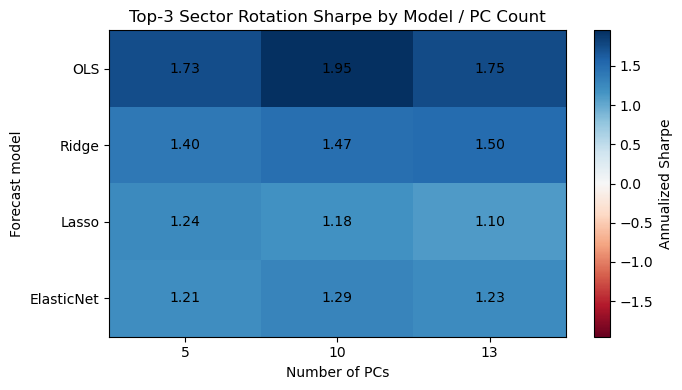

In [107]:
# Visual summary: Sharpe by model and PC count.
if not portfolio_summary.empty:
    sharpe_heat = portfolio_summary.pivot(index="model", columns="pc_count", values="sharpe").reindex(PORTFOLIO_MODELS)
    fig, ax = plt.subplots(figsize=(7, 4))
    vmax = max(abs(np.nanmin(sharpe_heat.values)), abs(np.nanmax(sharpe_heat.values)), 0.5)
    im = ax.imshow(sharpe_heat.values.astype(float), cmap="RdBu", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_xticks(np.arange(len(sharpe_heat.columns)))
    ax.set_xticklabels(sharpe_heat.columns)
    ax.set_yticks(np.arange(len(sharpe_heat.index)))
    ax.set_yticklabels(sharpe_heat.index)
    ax.set_title(f"Top-{TOP_N_SECTORS} Sector Rotation Sharpe by Model / PC Count")
    ax.set_xlabel("Number of PCs")
    ax.set_ylabel("Forecast model")

    for i in range(sharpe_heat.shape[0]):
        for j in range(sharpe_heat.shape[1]):
            value = sharpe_heat.iloc[i, j]
            label = "" if pd.isna(value) else f"{value:.2f}"
            ax.text(j, i, label, ha="center", va="center", color="black", fontsize=10)

    fig.colorbar(im, ax=ax, label="Annualized Sharpe")
    plt.tight_layout()
    plt.show()


In [108]:
# Save portfolio alpha-test outputs.
portfolio_backtests.to_csv(RESULTS_DATA_DIR / "portfolio_backtests.csv", index=False)
portfolio_summary.to_csv(RESULTS_DATA_DIR / "portfolio_summary.csv", index=False)

print("Saved portfolio files:")
print("  portfolio_backtests.csv")
print("  portfolio_summary.csv")


Saved portfolio files:
  portfolio_backtests.csv
  portfolio_summary.csv


## 7. Portfolio robustness checks

Stress-test the sector-rotation result with alternative portfolio rules: top-1, top-3, and top-5 long-only portfolios; a top-3 minus bottom-3 long-short spread; and a simple sector momentum benchmark.

In [109]:
# Portfolio robustness checks: concentration, long-short spread, and momentum benchmark.
ROBUSTNESS_MODEL = "Ridge"
ROBUSTNESS_PC_COUNT = 10
ROBUSTNESS_HORIZON = 1
ROBUSTNESS_TOP_NS = [1, 3, 5]
LONG_SHORT_N = 3


def strategy_metrics(name, returns, spy_returns=None, equal_weight_returns=None):
    row = {
        "strategy": name,
        "n_months": len(returns.dropna()),
        "ann_return": annualized_return(returns),
        "ann_volatility": annualized_volatility(returns),
        "sharpe": annualized_sharpe(returns),
        "max_drawdown": max_drawdown(returns),
    }
    if spy_returns is not None:
        aligned = pd.concat([returns.rename("strategy"), spy_returns.rename("spy")], axis=1).dropna()
        row["ann_excess_return_vs_spy"] = (aligned["strategy"] - aligned["spy"]).mean() * 12 if not aligned.empty else np.nan
        row["excess_sharpe_vs_spy"] = annualized_sharpe(aligned["strategy"] - aligned["spy"]) if not aligned.empty else np.nan
    if equal_weight_returns is not None:
        aligned = pd.concat([returns.rename("strategy"), equal_weight_returns.rename("equal_weight")], axis=1).dropna()
        row["ann_excess_return_vs_equal_weight"] = (aligned["strategy"] - aligned["equal_weight"]).mean() * 12 if not aligned.empty else np.nan
    return row


def get_forecast_ranks(predictions, model=ROBUSTNESS_MODEL, pc_count=ROBUSTNESS_PC_COUNT, horizon=ROBUSTNESS_HORIZON):
    subset = predictions[
        (predictions["target_type"] == PORTFOLIO_TARGET_TYPE)
        & (predictions["model"] == model)
        & (predictions["pc_count"] == pc_count)
        & (predictions["horizon"] == horizon)
    ].copy()
    subset["date"] = pd.to_datetime(subset["date"])
    subset["sector"] = subset["target"].str.replace("_excess", "", regex=False)
    subset = subset[subset["sector"].isin(sector_raw_for_port.columns)]
    return subset


def build_long_only_from_ranks(ranked_predictions, top_n):
    rows = []
    holdings_by_date = []
    for date, date_preds in ranked_predictions.groupby("date"):
        if date not in sector_raw_for_port.index or date not in spy_for_port.index:
            continue
        selected = date_preds.dropna(subset=["prediction"]).sort_values("prediction", ascending=False).head(top_n)["sector"].tolist()
        raw_returns = sector_raw_for_port.loc[date, selected].dropna()
        if raw_returns.empty:
            continue
        selected = raw_returns.index.tolist()
        holdings_by_date.append((date, selected))
        rows.append({
            "date": date,
            "strategy": f"Google/PCA top-{top_n}",
            "return": raw_returns.mean(),
            "holdings": ", ".join(selected),
        })
    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.sort_values("date").set_index("date")
    return out, average_turnover(holdings_by_date)


def build_long_short_from_ranks(ranked_predictions, n=LONG_SHORT_N):
    rows = []
    for date, date_preds in ranked_predictions.groupby("date"):
        if date not in sector_raw_for_port.index:
            continue
        ordered = date_preds.dropna(subset=["prediction"]).sort_values("prediction", ascending=False)
        longs = ordered.head(n)["sector"].tolist()
        shorts = ordered.tail(n)["sector"].tolist()
        long_returns = sector_raw_for_port.loc[date, longs].dropna()
        short_returns = sector_raw_for_port.loc[date, shorts].dropna()
        if long_returns.empty or short_returns.empty:
            continue
        rows.append({
            "date": date,
            "strategy": f"Google/PCA long top-{n} short bottom-{n}",
            "return": long_returns.mean() - short_returns.mean(),
            "longs": ", ".join(long_returns.index.tolist()),
            "shorts": ", ".join(short_returns.index.tolist()),
        })
    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.sort_values("date").set_index("date")
    return out


def build_momentum_strategy(top_n=3, dates=None):
    rows = []
    holdings_by_date = []
    candidate_dates = pd.Index(dates).sort_values() if dates is not None else sector_raw_for_port.index
    for date in candidate_dates:
        if date not in sector_raw_for_port.index or date not in spy_for_port.index:
            continue
        loc = sector_raw_for_port.index.get_loc(date)
        if isinstance(loc, slice) or loc == 0:
            continue
        prev_date = sector_raw_for_port.index[loc - 1]
        prev_returns = sector_raw_for_port.loc[prev_date].dropna().sort_values(ascending=False)
        selected = prev_returns.head(top_n).index.tolist()
        raw_returns = sector_raw_for_port.loc[date, selected].dropna()
        if raw_returns.empty:
            continue
        selected = raw_returns.index.tolist()
        holdings_by_date.append((date, selected))
        rows.append({
            "date": date,
            "strategy": f"Momentum top-{top_n}",
            "return": raw_returns.mean(),
            "holdings": ", ".join(selected),
        })
    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.sort_values("date").set_index("date")
    return out, average_turnover(holdings_by_date)


ranked_predictions = get_forecast_ranks(oos_predictions)
robustness_returns = {}
robustness_holdings = {}
robustness_rows = []
turnover_rows = []

common_dates = sorted(ranked_predictions["date"].unique())
spy_common = spy_for_port.loc[spy_for_port.index.isin(common_dates)]
equal_weight_common = sector_raw_for_port.loc[sector_raw_for_port.index.isin(common_dates)].mean(axis=1)

for top_n in ROBUSTNESS_TOP_NS:
    strat, turnover = build_long_only_from_ranks(ranked_predictions, top_n=top_n)
    if not strat.empty:
        name = f"Google/PCA top-{top_n}"
        robustness_returns[name] = strat["return"]
        robustness_holdings[name] = strat
        robustness_rows.append(strategy_metrics(name, strat["return"], spy_common, equal_weight_common))
        turnover_rows.append({"strategy": name, "avg_monthly_turnover": turnover})

long_short = build_long_short_from_ranks(ranked_predictions, n=LONG_SHORT_N)
if not long_short.empty:
    name = f"Google/PCA long top-{LONG_SHORT_N} short bottom-{LONG_SHORT_N}"
    robustness_returns[name] = long_short["return"]
    robustness_holdings[name] = long_short
    robustness_rows.append(strategy_metrics(name, long_short["return"], None, None))

momentum, momentum_turnover = build_momentum_strategy(top_n=3, dates=common_dates)
if not momentum.empty:
    name = "Momentum top-3"
    robustness_returns[name] = momentum["return"]
    robustness_holdings[name] = momentum
    robustness_rows.append(strategy_metrics(name, momentum["return"], spy_common, equal_weight_common))
    turnover_rows.append({"strategy": name, "avg_monthly_turnover": momentum_turnover})

robustness_rows.append(strategy_metrics("SPY", spy_common, None, None))
robustness_rows.append(strategy_metrics("Equal-weight sectors", equal_weight_common, spy_common, None))

portfolio_robustness_summary = pd.DataFrame(robustness_rows)
turnover_df = pd.DataFrame(turnover_rows)
if not turnover_df.empty:
    portfolio_robustness_summary = portfolio_robustness_summary.merge(turnover_df, on="strategy", how="left")

print(f"Robustness strategies use {ROBUSTNESS_MODEL}, {ROBUSTNESS_PC_COUNT} PCs, t+{ROBUSTNESS_HORIZON} forecasts where applicable.")
display(portfolio_robustness_summary.sort_values("sharpe", ascending=False).round(4))


Robustness strategies use Ridge, 10 PCs, t+1 forecasts where applicable.


,strategy,n_months,ann_return,ann_volatility,sharpe,max_drawdown,ann_excess_return_vs_spy,excess_sharpe_vs_spy,ann_excess_return_vs_equal_weight,avg_monthly_turnover
3,Google/PCA long top-3 short bottom-3,59,0.2755,0.1237,2.0482,-0.1200,NaN,NaN,NaN,NaN
0,Google/PCA top-1,59,0.3342,0.1984,1.5647,-0.1151,0.1738,1.3354,0.1948,0.3966
1,Google/PCA top-3,59,0.2639,0.1702,1.4715,-0.1823,0.1139,1.9563,0.1349,0.2931
2,Google/PCA top-5,59,0.2201,0.1692,1.2675,-0.1566,0.0780,1.3415,0.0990,0.1931
5,SPY,59,0.1310,0.1613,0.8464,-0.2397,NaN,NaN,NaN,NaN
4,Momentum top-3,59,0.1220,0.1537,0.8280,-0.1957,-0.0092,-0.0838,0.0118,0.6839
6,Equal-weight sectors,59,0.1096,0.1497,0.7717,-0.1831,-0.0210,-0.3668,NaN,NaN


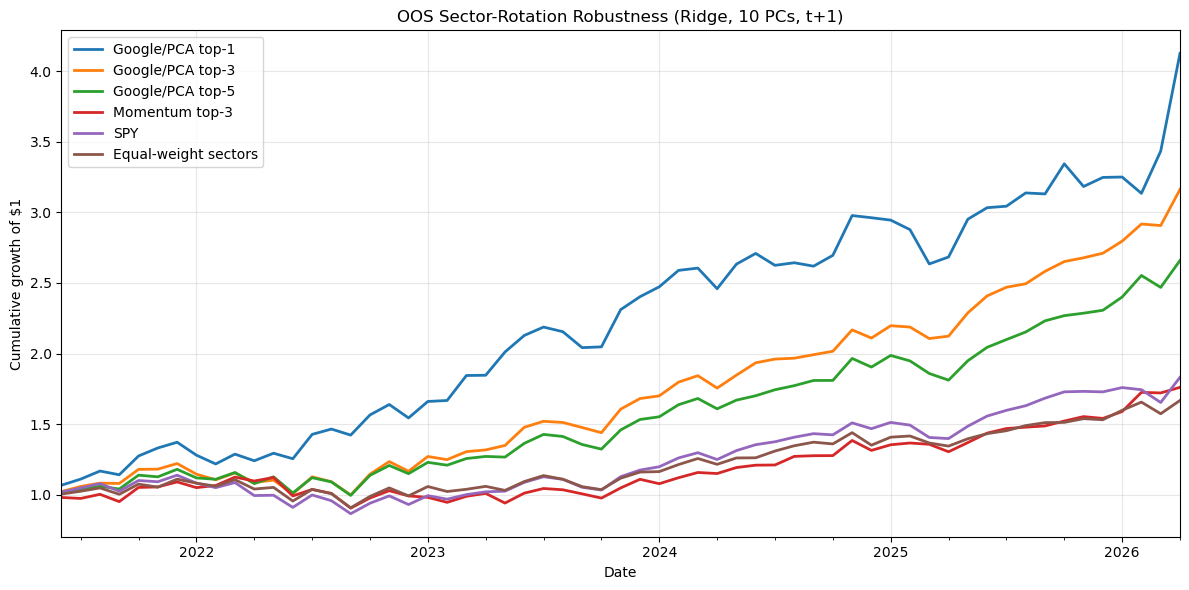

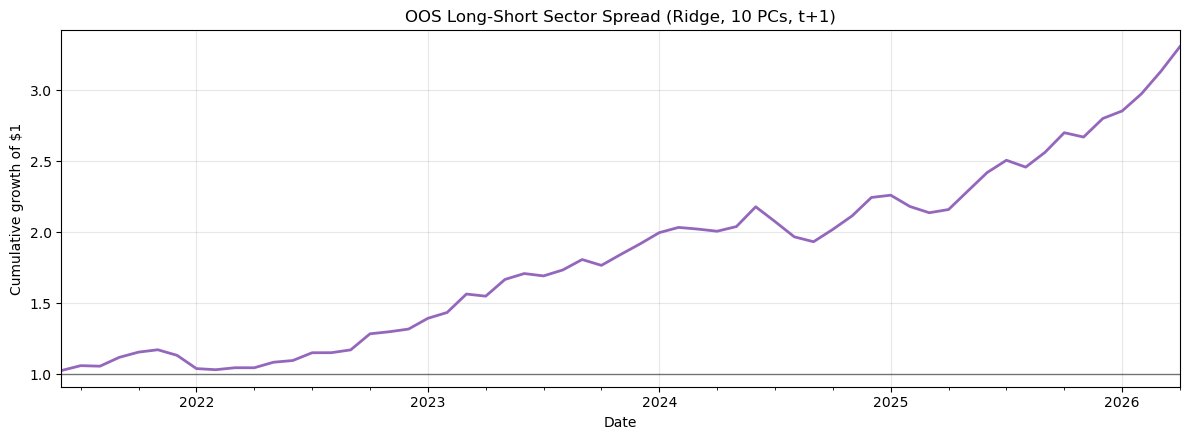

In [110]:
# Cumulative performance figure for portfolio robustness checks.
plot_series = {
    "Google/PCA top-1": robustness_returns.get("Google/PCA top-1"),
    "Google/PCA top-3": robustness_returns.get("Google/PCA top-3"),
    "Google/PCA top-5": robustness_returns.get("Google/PCA top-5"),
    "Momentum top-3": robustness_returns.get("Momentum top-3"),
    "SPY": spy_common,
    "Equal-weight sectors": equal_weight_common,
}
plot_series = {name: series for name, series in plot_series.items() if series is not None and not series.empty}

cumulative_robustness = pd.DataFrame({
    name: (1 + series.dropna()).cumprod()
    for name, series in plot_series.items()
})

fig, ax = plt.subplots(figsize=(12, 6))
cumulative_robustness.plot(ax=ax, linewidth=2)
ax.set_title(f"OOS Sector-Rotation Robustness ({ROBUSTNESS_MODEL}, {ROBUSTNESS_PC_COUNT} PCs, t+{ROBUSTNESS_HORIZON})")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative growth of $1")
ax.grid(True, alpha=0.3)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

# Long-short is dollar-neutral, so plot it separately as cumulative return on the spread.
ls_name = f"Google/PCA long top-{LONG_SHORT_N} short bottom-{LONG_SHORT_N}"
if ls_name in robustness_returns:
    cumulative_long_short = (1 + robustness_returns[ls_name].dropna()).cumprod()
    fig, ax = plt.subplots(figsize=(12, 4.5))
    cumulative_long_short.plot(ax=ax, linewidth=2, color="tab:purple")
    ax.axhline(1.0, color="black", linewidth=1, alpha=0.5)
    ax.set_title(f"OOS Long-Short Sector Spread ({ROBUSTNESS_MODEL}, {ROBUSTNESS_PC_COUNT} PCs, t+{ROBUSTNESS_HORIZON})")
    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative growth of $1")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [111]:
# Save robustness outputs.
robustness_backtest_frames = []
for name, frame in robustness_holdings.items():
    saved = frame.reset_index().copy()
    saved["strategy"] = name
    robustness_backtest_frames.append(saved)

portfolio_robustness_backtests = pd.concat(robustness_backtest_frames, ignore_index=True) if robustness_backtest_frames else pd.DataFrame()
portfolio_robustness_summary.to_csv(RESULTS_DATA_DIR / "portfolio_robustness_summary.csv", index=False)
portfolio_robustness_backtests.to_csv(RESULTS_DATA_DIR / "portfolio_robustness_backtests.csv", index=False)

print("Saved portfolio robustness files:")
print("  portfolio_robustness_summary.csv")
print("  portfolio_robustness_backtests.csv")


Saved portfolio robustness files:
  portfolio_robustness_summary.csv
  portfolio_robustness_backtests.csv


## 8. Transaction cost robustness

Apply simple one-way transaction costs to the long-only sector-rotation strategies. Costs are charged as `cost_bps * monthly_turnover`, where turnover is the fraction of the portfolio traded that month.

In [112]:
# Transaction cost robustness for long-only sector rotation strategies.
TRANSACTION_COST_BPS = [0, 5, 10, 25]
TC_STRATEGIES = ["Google/PCA top-1", "Google/PCA top-3", "Google/PCA top-5", "Momentum top-3"]


def add_turnover_to_long_only(frame, weight_col_prefix="weight"):
    data = frame.reset_index().copy()
    data["date"] = pd.to_datetime(data["date"])
    data["holding_list"] = data["holdings"].fillna("").apply(lambda x: [item.strip() for item in x.split(",") if item.strip()])

    rows = []
    previous_weights = None
    for _, row in data.sort_values("date").iterrows():
        holdings = row["holding_list"]
        current_weights = {sector: 1 / len(holdings) for sector in holdings} if holdings else {}
        if previous_weights is None:
            turnover = sum(abs(weight) for weight in current_weights.values())
        else:
            names = set(previous_weights) | set(current_weights)
            turnover = 0.5 * sum(abs(current_weights.get(name, 0) - previous_weights.get(name, 0)) for name in names)
        out = row.drop(labels=["holding_list"]).to_dict()
        out["turnover"] = turnover
        rows.append(out)
        previous_weights = current_weights

    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.sort_values("date").set_index("date")
    return out


tc_rows = []
tc_return_frames = []

for strategy_name in TC_STRATEGIES:
    if strategy_name not in robustness_holdings:
        continue
    gross_frame = add_turnover_to_long_only(robustness_holdings[strategy_name])
    if gross_frame.empty:
        continue

    for cost_bps in TRANSACTION_COST_BPS:
        cost_decimal = cost_bps / 10000
        net_returns = gross_frame["return"] - cost_decimal * gross_frame["turnover"]
        tc_rows.append({
            "strategy": strategy_name,
            "cost_bps": cost_bps,
            "n_months": len(net_returns.dropna()),
            "avg_monthly_turnover": gross_frame["turnover"].mean(),
            "ann_return": annualized_return(net_returns),
            "ann_volatility": annualized_volatility(net_returns),
            "sharpe": annualized_sharpe(net_returns),
            "max_drawdown": max_drawdown(net_returns),
            "final_cumulative_growth": (1 + net_returns.dropna()).prod(),
        })

        saved = gross_frame[["return", "turnover", "holdings"]].copy()
        saved["strategy"] = strategy_name
        saved["cost_bps"] = cost_bps
        saved["net_return"] = net_returns
        tc_return_frames.append(saved.reset_index())

portfolio_tc_summary = pd.DataFrame(tc_rows)
portfolio_tc_returns = pd.concat(tc_return_frames, ignore_index=True) if tc_return_frames else pd.DataFrame()

print("Transaction-cost robustness summary:")
display(
    portfolio_tc_summary
    .pivot(index="strategy", columns="cost_bps", values="sharpe")
    .reindex(TC_STRATEGIES)
    .round(3)
)

display(
    portfolio_tc_summary
    .pivot(index="strategy", columns="cost_bps", values="ann_return")
    .reindex(TC_STRATEGIES)
    .round(3)
)


Transaction-cost robustness summary:


cost_bps,0,5,10,25
strategy,,,,
Google/PCA top-1,1.565,1.553,1.541,1.504
Google/PCA top-3,1.471,1.461,1.450,1.418
Google/PCA top-5,1.268,1.260,1.253,1.232
Momentum top-3,0.828,0.801,0.774,0.694


cost_bps,0,5,10,25
strategy,,,,
Google/PCA top-1,0.334,0.331,0.328,0.318
Google/PCA top-3,0.264,0.262,0.259,0.253
Google/PCA top-5,0.220,0.219,0.217,0.213
Momentum top-3,0.122,0.117,0.113,0.099


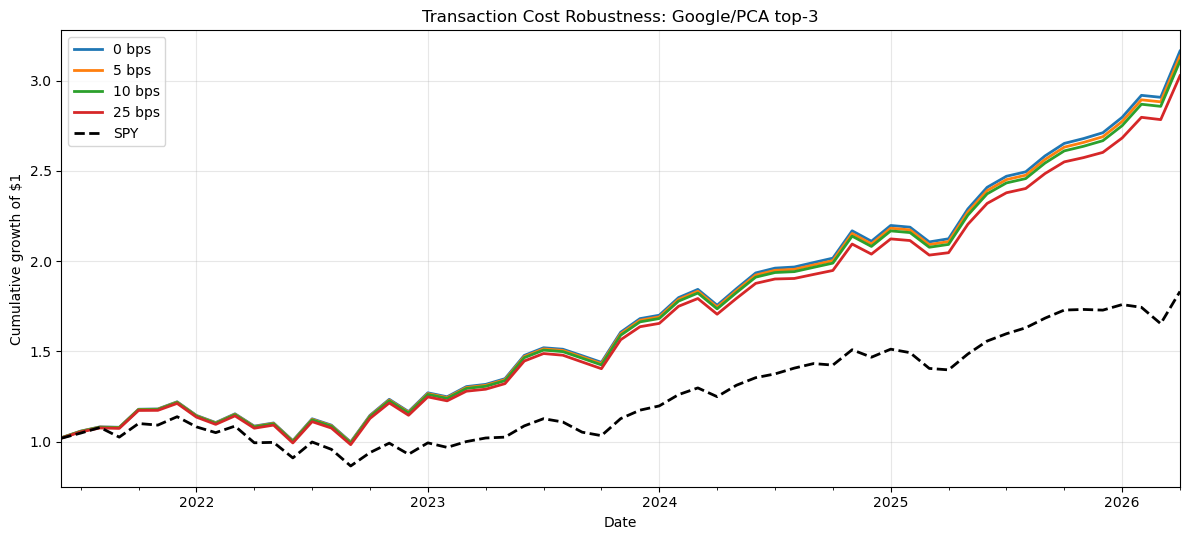

In [113]:
# Plot net cumulative performance for the main top-3 strategy under transaction costs.
MAIN_TC_STRATEGY = "Google/PCA top-3"
main_tc = portfolio_tc_returns[portfolio_tc_returns["strategy"] == MAIN_TC_STRATEGY].copy()

if main_tc.empty:
    print("No transaction-cost results available for the selected strategy.")
else:
    main_tc["date"] = pd.to_datetime(main_tc["date"])
    net_cumulative = (
        main_tc
        .pivot(index="date", columns="cost_bps", values="net_return")
        .sort_index()
        .apply(lambda s: (1 + s.dropna()).cumprod())
    )
    net_cumulative.columns = [f"{int(col)} bps" for col in net_cumulative.columns]

    fig, ax = plt.subplots(figsize=(12, 5.5))
    net_cumulative.plot(ax=ax, linewidth=2)
    spy_growth = (1 + spy_common.dropna()).cumprod()
    spy_growth.plot(ax=ax, color="black", linestyle="--", linewidth=2, label="SPY")
    ax.set_title(f"Transaction Cost Robustness: {MAIN_TC_STRATEGY}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative growth of $1")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=True)
    plt.tight_layout()
    plt.show()


In [114]:
# Save transaction cost outputs.
portfolio_tc_summary.to_csv(RESULTS_DATA_DIR / "portfolio_transaction_cost_summary.csv", index=False)
portfolio_tc_returns.to_csv(RESULTS_DATA_DIR / "portfolio_transaction_cost_returns.csv", index=False)

print("Saved transaction cost files:")
print("  portfolio_transaction_cost_summary.csv")
print("  portfolio_transaction_cost_returns.csv")


Saved transaction cost files:
  portfolio_transaction_cost_summary.csv
  portfolio_transaction_cost_returns.csv
